# 02 · Uncertainty of Boltz-2 head-FT predictions (all targets, self-filling)

Question: which confidence signals can be trusted when we screen with the fine-tuned head, and how uncertain is the benchmark number itself? Re-run the notebook after more targets finish; every target with all 16 eval arms scored (No-FT + head-FT N=40/100/300 x 5 seeds) is processed, others show a `pending` note and an empty panel. Heavy bootstraps are cached in `results/analysis/<target>/uncertainty_cache.pkl`.

**Confidence measures** (high = uncertain): cross-seed SD of the head-FT probability (5 seeds, N=300), two-head disagreement `|head1-head2|` (No-FT and FT), seed votes (in how many of 5 seeds a compound is in the seed's own top 1%), and, where a `qc.csv` of Boltz-2 pose confidence exists for the target, ligand ipTM and complex PDE.

**Replication note.** The paper (Furui & Ohue) reports per-target AP/EF of No-FT vs head-FT but no uncertainty analysis, so the uncertainty sections are extensions; wherever the paper reports a number (No-FT AP, FT AP) it is shown beside ours and is labelled as a fixed paper value. **Statistics.** Resampling within target is a bootstrap over compounds (1000 replicates for ratios/precision, 500 for AP; groups/sets are held fixed, i.e. conditional on the selection). Cross-target statements treat targets as the unit.

In [1]:

import sys, warnings, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
warnings.filterwarnings("ignore")
sys.path.insert(0, "/global/scratch/users/sergiomar10/boltzaff/pipeline_local")
from bft_common import *
from bft_uncertainty import *
style()
R, D, PEND = {}, {}, {}
for t in TARGETS:
    try:
        r = analyze(t)
        if r is None: PEND[t] = pending_reason(t) or "scores unavailable"
        else: R[t] = r; D[t] = load(t)
    except Exception as e:
        PEND[t] = f"error while analysing: {type(e).__name__}: {e}"
display(status())
for t in TARGETS: print(("filled   " if t in R else "pending  ") + t + ("" if t in R else ": " + PEND[t]))
NT = len(R); print(f"\n{NT} of {len(TARGETS)} targets analysed.  Pooled cross-target statements need >= 3 targets for an interval; fewer are descriptive only.")

class Pend(Exception): pass
def pend(ax, msg):
    ax.text(0.5, 0.5, "pending:\n" + msg, ha="center", va="center", transform=ax.transAxes, fontsize=9, wrap=True)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
def panels(draw, title, figsize=(18, 8.5), nr=2, nc=4):
    fig, axes = plt.subplots(nr, nc, figsize=figsize); axes = axes.ravel()
    for ax, t in zip(axes, TARGETS):
        ax.set_title(f"target {t}", fontsize=10)
        if t not in R: pend(ax, PEND.get(t, "?")); continue
        try: draw(ax, t)
        except Pend as e: pend(ax, str(e))
        except Exception as e: pend(ax, f"error: {type(e).__name__}: {e}")
    fig.suptitle(title, fontsize=12); fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()
def wilson(a, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = a / n; d = 1 + z * z / n; c = (p + z * z / (2 * n)) / d; h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (c - h, c + h)
def slot_axis(ax):
    ax.set_xticks(range(len(TARGETS))); ax.set_xticklabels([SHORT[t] for t in TARGETS], rotation=30)
    for i, t in enumerate(TARGETS):
        if t not in R: ax.text(i, 0.02, "pending", rotation=90, ha="center", va="bottom", transform=ax.get_xaxis_transform(), fontsize=8)
ML = {"sd": "cross-seed SD (FT)", "dis_ft": "two-head (FT)", "dis0": "two-head (No-FT)", "iptm": "1 - ligand ipTM", "pde": "complex PDE"}
# sanity: our AP vs eval_headft_seeds.py output where it exists
for t in R:
    ps = per_seed(t)
    if ps is None: print(f"{SHORT[t]}: no per_seed.csv to cross-check"); continue
    ps = ps[(ps.n_train == 300) & (ps.arm != "base")] if "arm" in ps else ps[ps.n_train == 300]
    print(f"{SHORT[t]}: max |AP(ours) - AP(per_seed.csv)| over 5 seeds at N=300 = {np.max(np.abs(np.sort(ps.ap.values) - np.sort(R[t]['ap']['ft'][300]['seeds']))):.2e}")


,library,ft_inputs,arms_scored,table2
target,,,,
588689,49985,True,16/16,True
504329,49982,True,16/16,True
743445,49995,True,0/16,False
485317,49980,True,0/16,False
2097,49915,False,0/16,False
493091,49985,False,0/16,False
2650,49882,False,0/16,False
588549,49987,False,0/16,False


filled   588689
filled   504329
pending  1053173-743445: only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending  493248-485317: only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending  434954-2097: ft_inputs / eval set not built yet
pending  540297-493091: ft_inputs / eval set not built yet
pending  463203-2650: ft_inputs / eval set not built yet
pending  624273-588549: ft_inputs / eval set not built yet

2 of 8 targets analysed.  Pooled cross-target statements need >= 3 targets for an interval; fewer are descriptive only.
588689: max |AP(ours) - AP(per_seed.csv)| over 5 seeds at N=300 = 5.55e-17
504329: max |AP(ours) - AP(per_seed.csv)| over 5 seeds at N=300 = 5.55e-17


## Part 1. The uncertainty measures
### Fig 1. Cross-seed SD: whole library vs the top-1% picks
Cross-seed SD is tiny for the bulk of the library (scores near zero) and much larger among the picks, because SD grows with the score. This is why every usefulness test below compares at **matched score**.

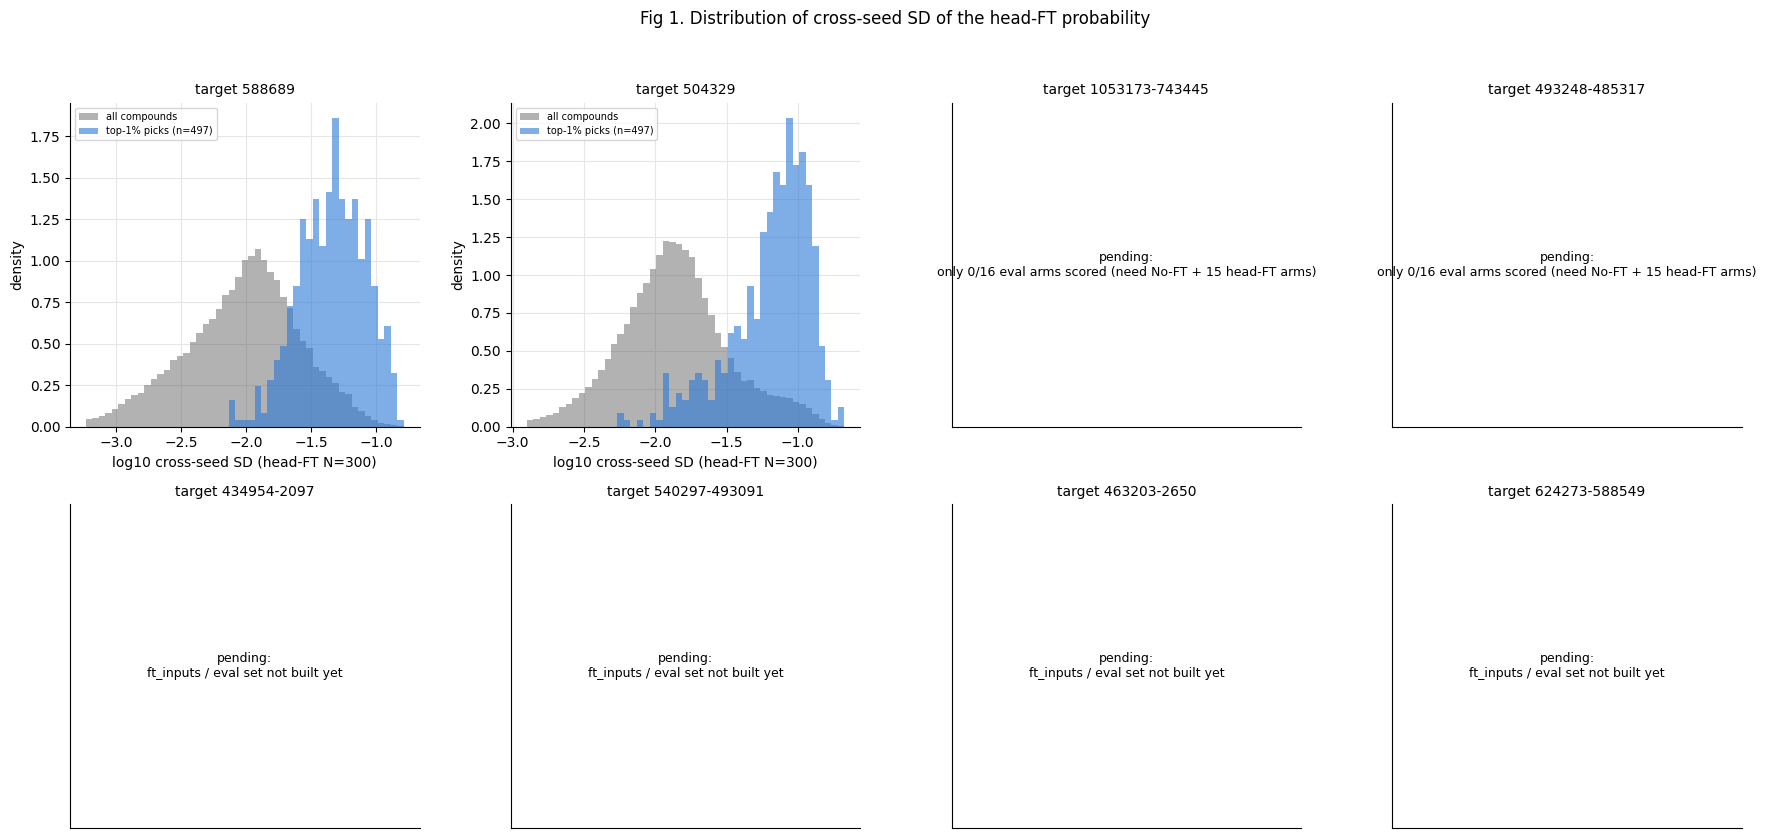

In [2]:
def d1(ax, t):
    d = D[t]; top = topk(d["pm"], R[t]["k"]); lo = np.log10(d["sd"] + 1e-6)
    bins = np.linspace(np.percentile(lo, 0.5), lo.max(), 50)
    ax.hist(lo, bins=bins, density=True, color=NEU, alpha=.5, label="all compounds")
    ax.hist(lo[top], bins=bins, density=True, color=OUR, alpha=.6, label=f"top-1% picks (n={len(top)})")
    ax.set_xlabel("log10 cross-seed SD (head-FT N=300)"); ax.set_ylabel("density"); ax.legend(fontsize=7)
panels(d1, "Fig 1. Distribution of cross-seed SD of the head-FT probability")

### Fig 2. Do the measures agree? (Spearman correlation among measures)
Columns: seed-mean FT probability (p), cross-seed SD, two-head disagreement FT, two-head No-FT, 1 - ligand ipTM (blank where no pose confidence).

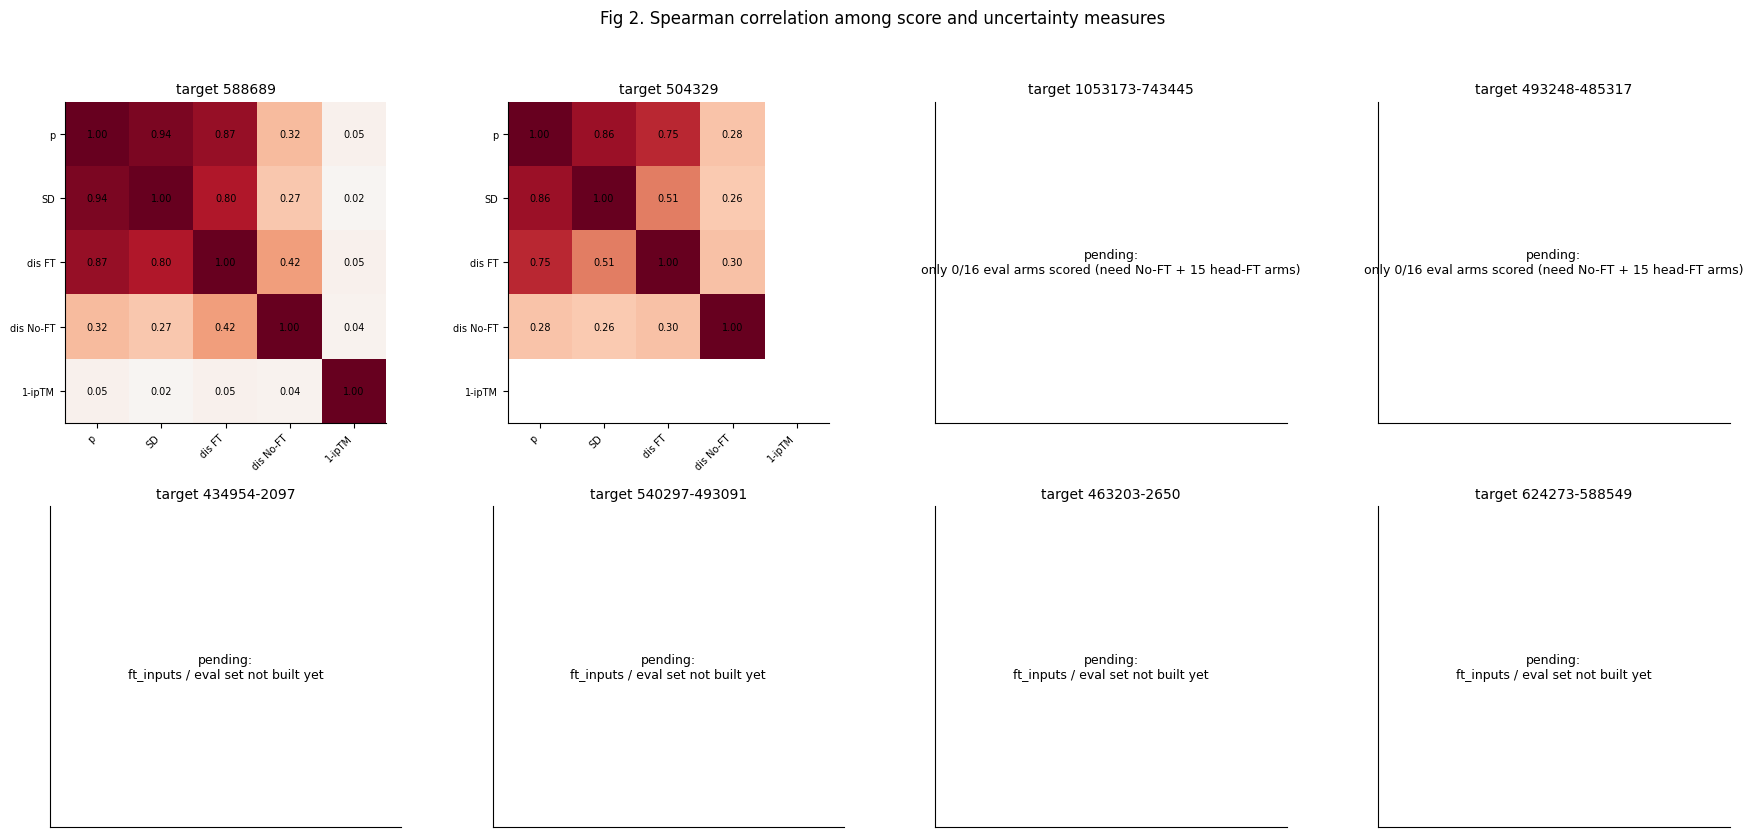

In [3]:
def d2(ax, t):
    d = D[t]; df = pd.DataFrame({"p": d["pm"], "SD": d["sd"], "dis FT": d["dis_ft"], "dis No-FT": d["dis0"], "1-ipTM": d["iptm"]})
    cc = df.corr(method="spearman"); v = cc.values
    ax.imshow(v, vmin=-1, vmax=1, cmap="RdBu_r"); ax.set_xticks(range(5)); ax.set_xticklabels(cc.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(5)); ax.set_yticklabels(cc.columns, fontsize=7); ax.grid(False)
    for i in range(5):
        for j in range(5): ax.text(j, i, "" if not np.isfinite(v[i, j]) else f"{v[i, j]:.2f}", ha="center", va="center", fontsize=7)
panels(d2, "Fig 2. Spearman correlation among score and uncertainty measures")

## Part 2. Is a confidence signal useful? (analysis 1)
Confidence correlates with score (SD rises with p), so comparing confident vs uncertain picks against the whole library is meaningless. We instead stratify the ranking into **13 rank bands** (top 1%, 1-2%, 2-5%, 5-10%, then deciles), split each band at the within-band median of the uncertainty measure (confident = at or below median), and compare the active rate of the two halves with a Mantel-Haenszel risk ratio RR = confident / uncertain. RR > 1 means confidence marks higher precision at matched score. No-FT two-head disagreement is matched on the No-FT score; all others on the seed-mean FT score.

### Fig 3. Active rate per rank band, confident vs uncertain half (cross-seed SD)

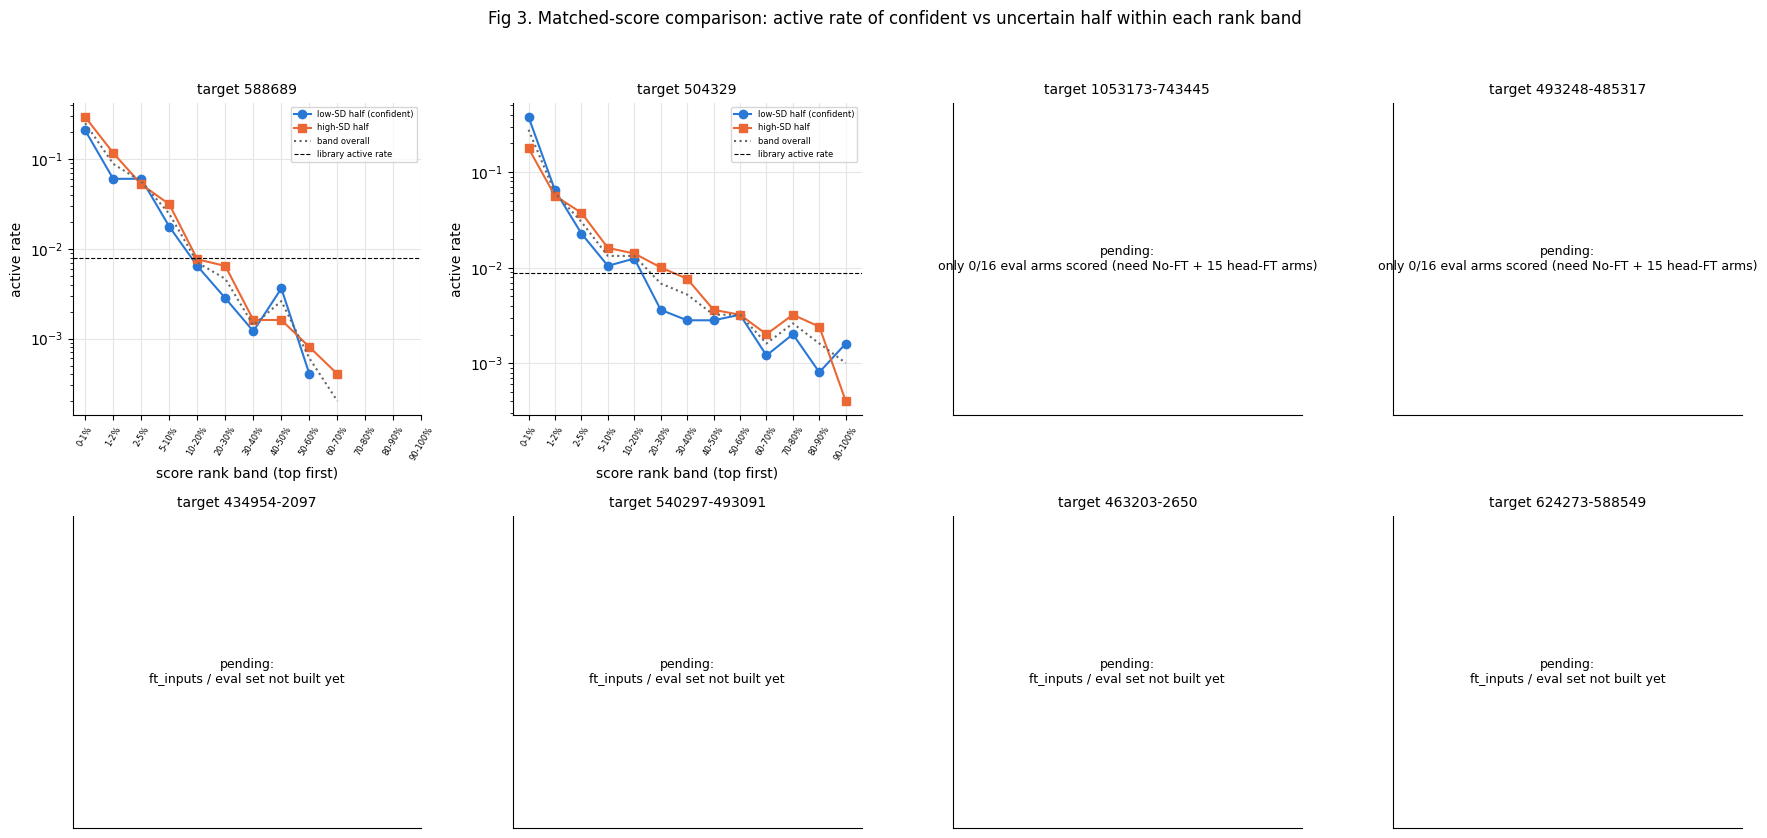

In [4]:
def d3(ax, t):
    v = R[t]["rr"]["sd"]; nb = len(BANDS) - 1; x = np.arange(nb)
    with np.errstate(all="ignore"):
        rc = v["a_conf"] / v["n_hi"]; ru = v["a_unc"] / v["n_lo"]; ra = (v["a_conf"] + v["a_unc"]) / (v["n_hi"] + v["n_lo"])
    ax.plot(x, np.where(rc > 0, rc, np.nan), "o-", color=OUR, label="low-SD half (confident)")
    ax.plot(x, np.where(ru > 0, ru, np.nan), "s-", color=THEIR, label="high-SD half")
    ax.plot(x, np.where(ra > 0, ra, np.nan), ":", color=NEU, label="band overall")
    ax.axhline(R[t]["rate"], color=BLK, lw=.8, ls="--", label="library active rate"); ax.set_yscale("log")
    ax.set_xticks(x); ax.set_xticklabels(BAND_LAB, rotation=60, fontsize=6); ax.set_xlabel("score rank band (top first)"); ax.set_ylabel("active rate"); ax.legend(fontsize=6)
panels(d3, "Fig 3. Matched-score comparison: active rate of confident vs uncertain half within each rank band")

### Fig 4. Mantel-Haenszel risk ratio for every measure, all targets
Markers: one per target, bars: bootstrap CI at the Bonferroni level (5 measures, so 99% percentile interval per target). Diamond: across-target geometric mean (target = unit) with a 95% t-interval only when >= 3 targets exist. The line RR = 1 is 'no value'.

pending: 1053173-743445 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 493248-485317 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 434954-2097 - ft_inputs / eval set not built yet
pending: 540297-493091 - ft_inputs / eval set not built yet
pending: 463203-2650 - ft_inputs / eval set not built yet
pending: 624273-588549 - ft_inputs / eval set not built yet


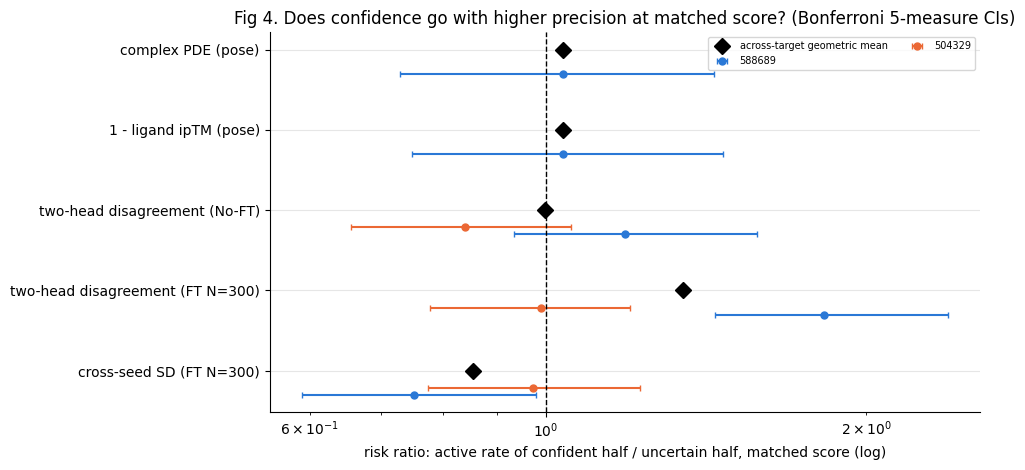

,target,measure,RR,lo_bonf,hi_bonf,n_used,note
0,588689,cross-seed SD (FT),0.751,0.590,0.978,49685.0,NaN
1,588689,two-head (FT),1.825,1.440,2.384,49685.0,NaN
2,588689,two-head (No-FT),1.186,0.933,1.578,49685.0,NaN
3,588689,1 - ligand ipTM,1.036,0.749,1.466,20923.0,NaN
4,588689,complex PDE,1.036,0.730,1.438,20923.0,NaN
5,504329,cross-seed SD (FT),0.971,0.774,1.227,49673.0,NaN
6,504329,two-head (FT),0.989,0.778,1.200,49673.0,NaN
7,504329,two-head (No-FT),0.840,0.656,1.055,49673.0,NaN
8,504329,1 - ligand ipTM,NaN,NaN,NaN,NaN,no pose confidence for this target
9,504329,complex PDE,NaN,NaN,NaN,NaN,no pose confidence for this target


In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8)); ms = list(MEAS); off = np.linspace(-.3, .3, len(TARGETS))
for j, t in enumerate(TARGETS):
    for i, m in enumerate(ms):
        if t not in R or R[t]["rr"].get(m) is None: continue
        v = R[t]["rr"][m]; lo, hi = np.nanpercentile(v["boot"], [0.5, 99.5])
        ax.errorbar(v["rr"], i + off[j], xerr=[[v["rr"] - lo], [hi - v["rr"]]], fmt="o", color=TCOL[t], ms=5, capsize=2, label=SHORT[t] if i == 0 else None)
for i, m in enumerate(ms):
    g = pooled([np.log(R[t]["rr"][m]["rr"]) for t in R if R[t]["rr"].get(m)])
    if g[3]: ax.plot(np.exp(g[0]), i, "D", color=BLK, ms=8, label="across-target geometric mean" if i == 0 else None)
    if g[1] is not None: ax.hlines(i, np.exp(g[1]), np.exp(g[2]), color=BLK, lw=2)
ax.axvline(1, color=BLK, ls="--", lw=1); ax.set_xscale("log"); ax.set_yticks(range(len(ms))); ax.set_yticklabels([MEAS[m] for m in ms])
ax.set_xlabel("risk ratio: active rate of confident half / uncertain half, matched score (log)")
ax.set_title("Fig 4. Does confidence go with higher precision at matched score? (Bonferroni 5-measure CIs)")
h, l = ax.get_legend_handles_labels()
if h: ax.legend(fontsize=7, ncol=2)
for t in TARGETS:
    if t not in R: print("pending:", t, "-", PEND[t])
plt.tight_layout(); plt.show()
rows = []
for t in R:
    for m in MEAS:
        v = R[t]["rr"].get(m)
        if v is None: rows.append(dict(target=SHORT[t], measure=ML[m], RR=np.nan, note="no pose confidence for this target")); continue
        lo, hi = np.nanpercentile(v["boot"], [0.5, 99.5]); rows.append(dict(target=SHORT[t], measure=ML[m], RR=v["rr"], lo_bonf=lo, hi_bonf=hi, n_used=v["n_used"]))
RRTAB = pd.DataFrame(rows); display(RRTAB.round(3))

### Fig 5. Abstention among the top-1% picks (risk-coverage)
Sort the top-1% picks by each uncertainty measure (most confident first) and track precision of the kept fraction. A useful measure would sit above the dashed line (precision of all picks); a measure that goes the wrong way would fall below it.

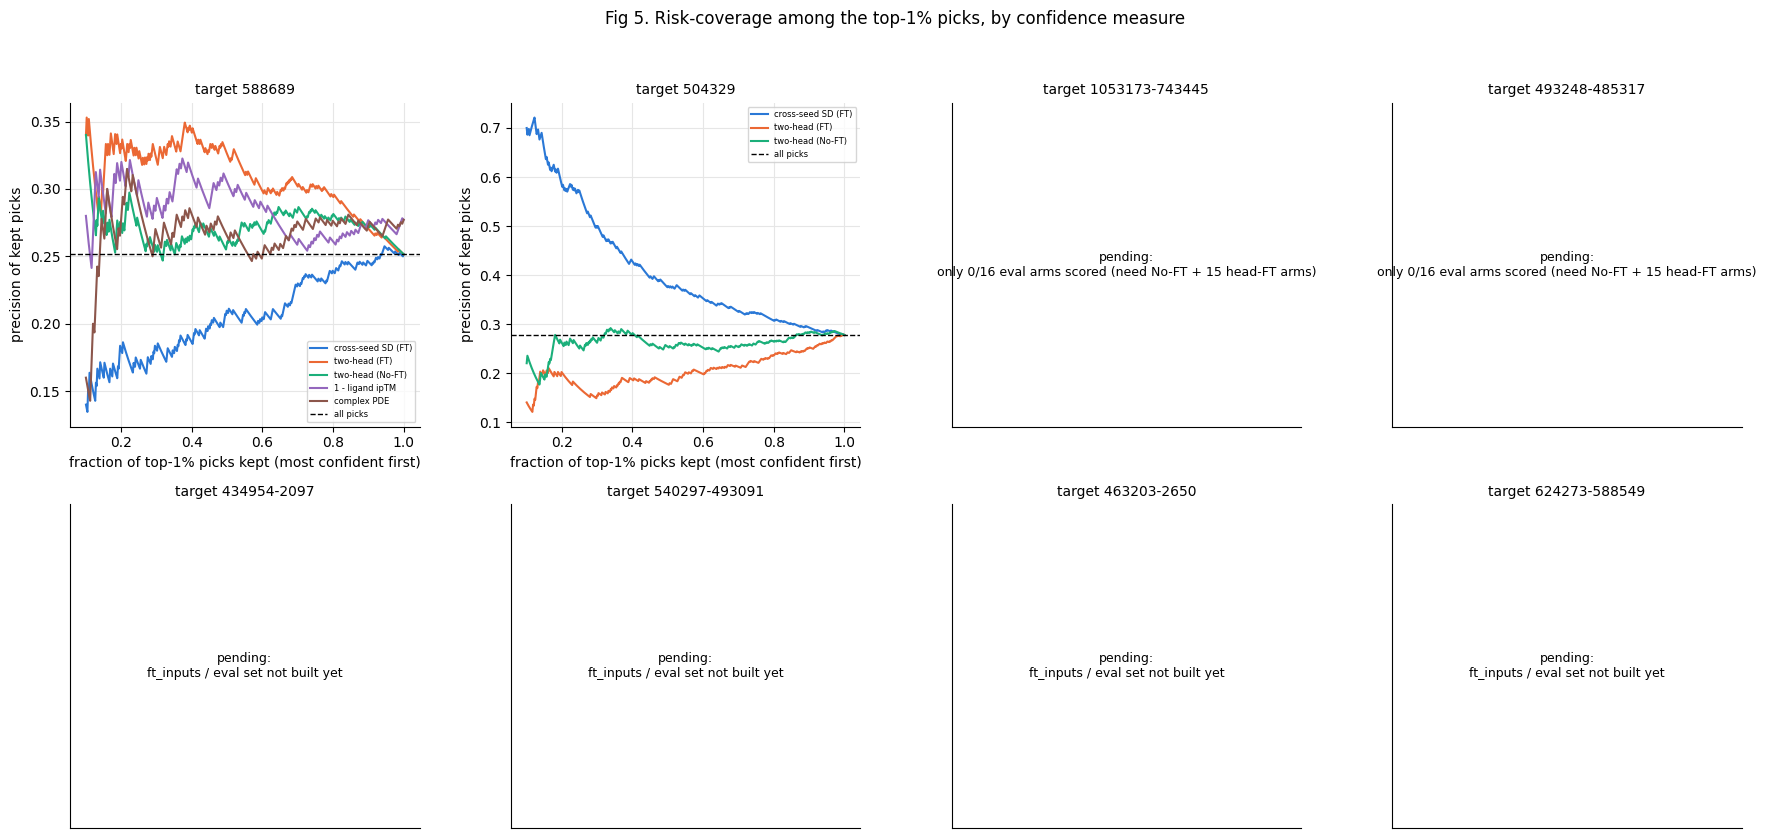

In [6]:
def d5(ax, t):
    for m, v in R[t]["riskcov"].items():
        s = v["cov"] >= 0.1; ax.plot(v["cov"][s], v["prec"][s], color=MCOL[m], label=ML[m])
    base = list(R[t]["riskcov"].values())[0]["base"]
    ax.axhline(base, color=BLK, ls="--", lw=1, label="all picks"); ax.set_xlabel("fraction of top-1% picks kept (most confident first)"); ax.set_ylabel("precision of kept picks"); ax.legend(fontsize=6)
panels(d5, "Fig 5. Risk-coverage among the top-1% picks, by confidence measure")

### Fig 6. Cross-seed SD of actives vs inactives inside the top-5% band
Restricting to the top 5% of the seed-mean score removes most of the score confound. If actives are scored with *less* seed agreement than decoys, cross-seed SD would flag the wrong compounds.

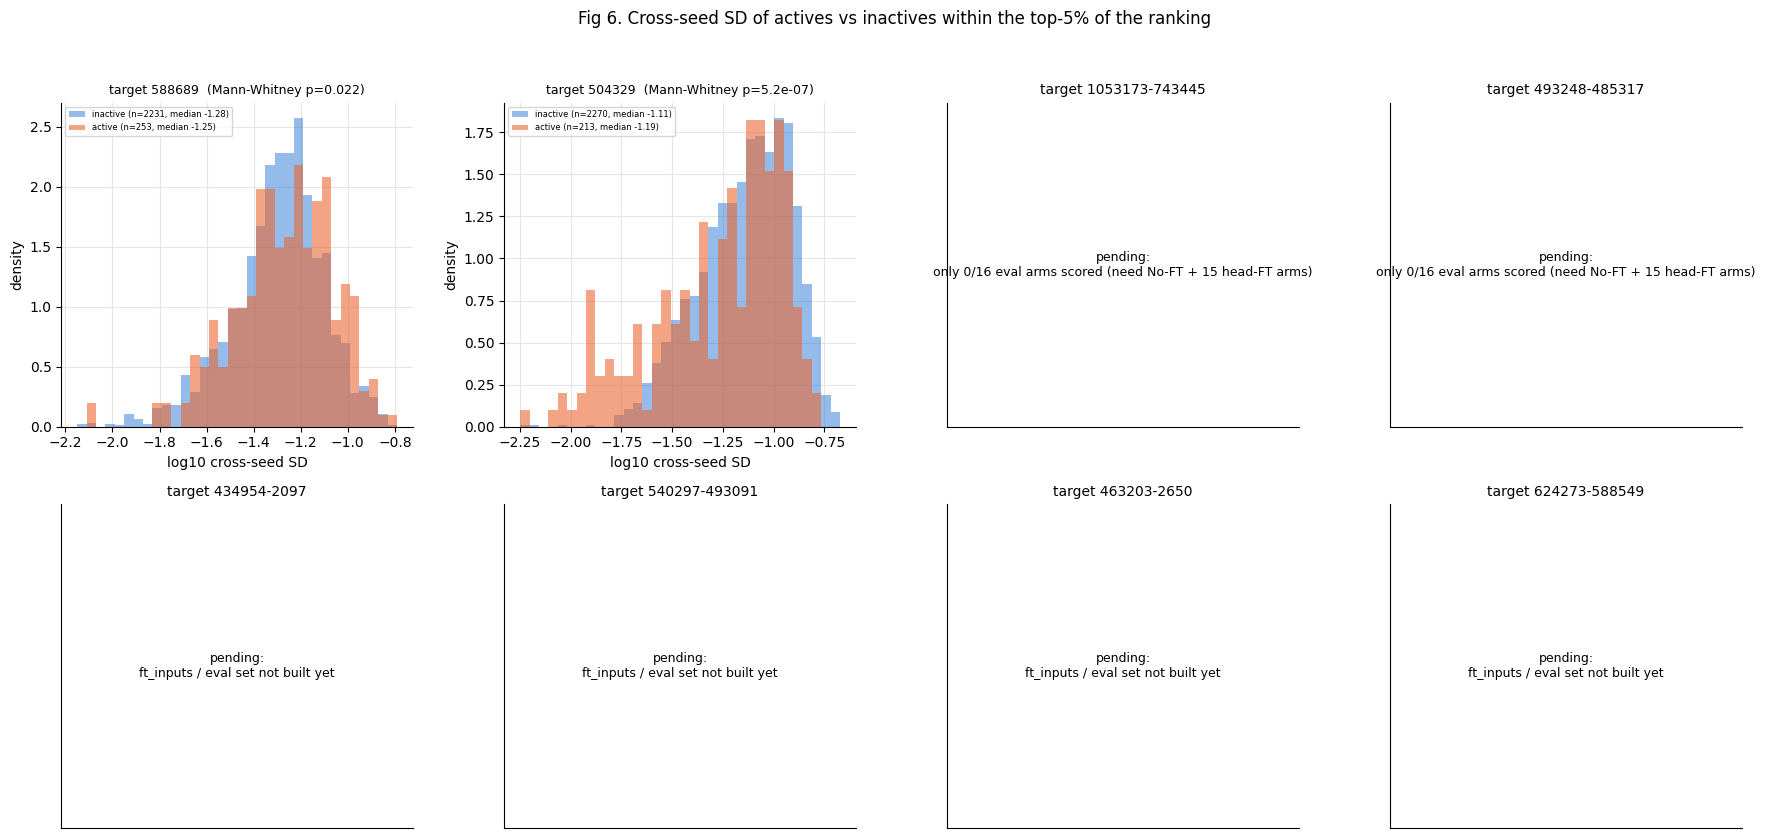

In [7]:
def d6(ax, t):
    d = D[t]; top = topk(d["pm"], int(0.05 * len(d["y"]))); y = d["y"][top]; s = np.log10(d["sd"][top] + 1e-6)
    a, i = s[y == 1], s[y == 0]; bins = np.linspace(s.min(), s.max(), 35)
    ax.hist(i, bins=bins, density=True, color=OUR, alpha=.5, label=f"inactive (n={len(i)}, median {np.median(i):.2f})")
    ax.hist(a, bins=bins, density=True, color=THEIR, alpha=.6, label=f"active (n={len(a)}, median {np.median(a):.2f})")
    p = stats.mannwhitneyu(a, i).pvalue; ax.set_title(f"target {t}  (Mann-Whitney p={p:.2g})", fontsize=9)
    ax.set_xlabel("log10 cross-seed SD"); ax.set_ylabel("density"); ax.legend(fontsize=6)
panels(d6, "Fig 6. Cross-seed SD of actives vs inactives within the top-5% of the ranking")

## Part 3. Calibration (analysis 2)
Reliability curve on 10 equal-mass bins and Expected Calibration Error (ECE = mass-weighted mean |mean predicted - observed rate|). The active rate is a fraction of a percent, so a probability output that is not recalibrated will sit far above the diagonal; ECE for ranking is secondary to AP but matters if the probability is read as a hit-rate.

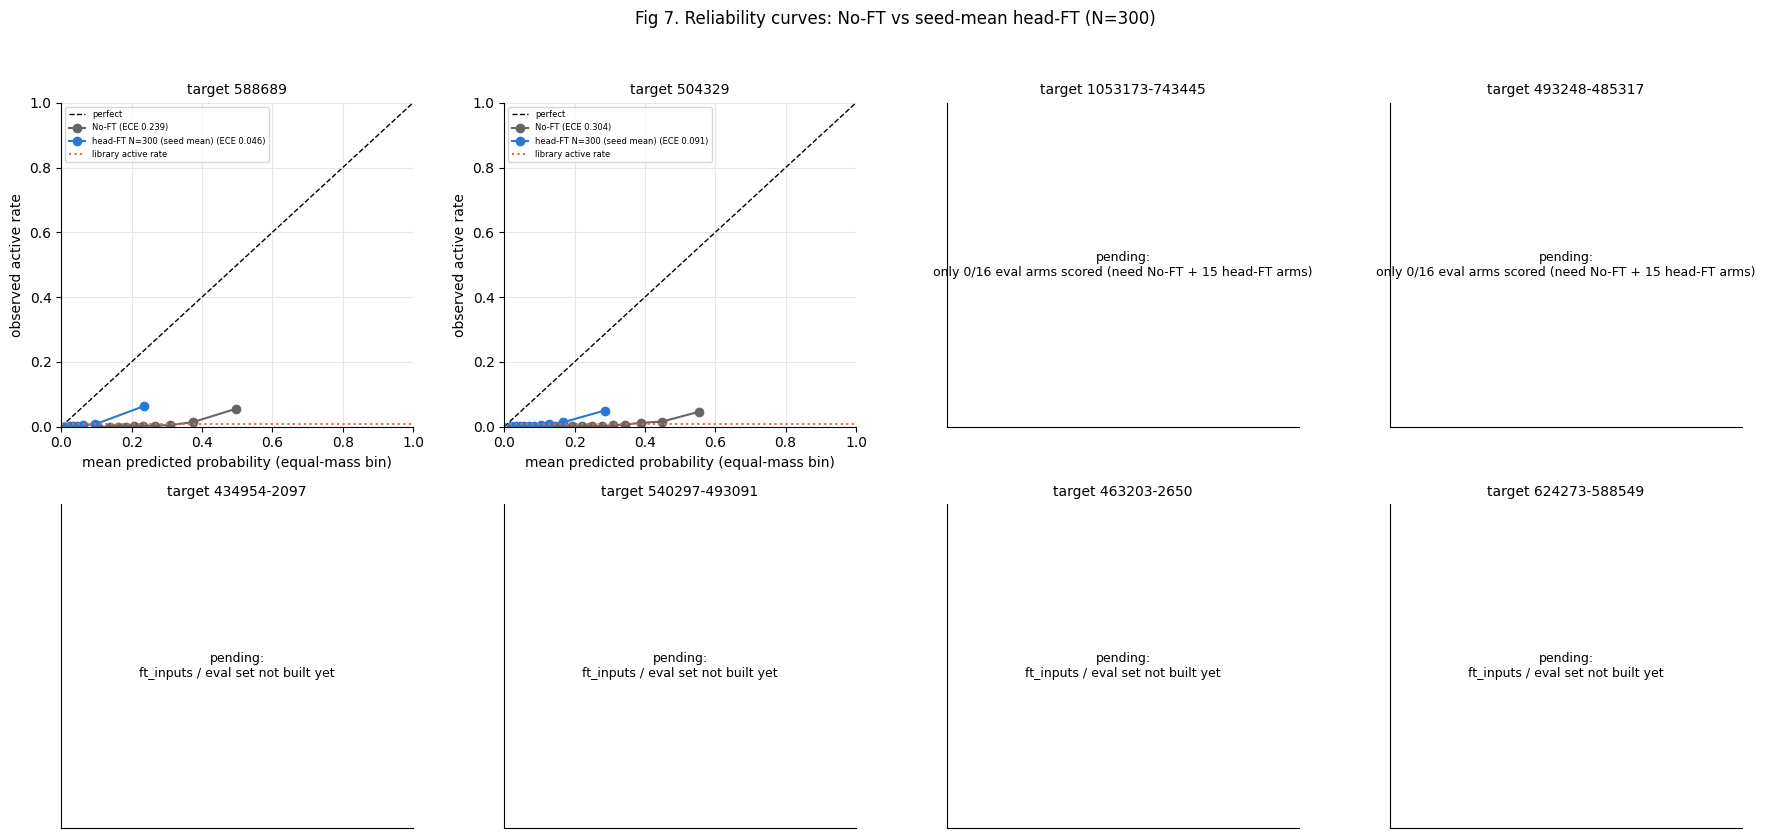

In [8]:
def d7(ax, t):
    ax.plot([0, 1], [0, 1], "--", color=BLK, lw=1, label="perfect")
    for (nm, v), c in zip([(k, R[t]["cal"][k]) for k in ("No-FT", "head-FT N=300 (seed mean)")], (NEU, OUR)):
        ax.plot(v["pm"], v["rate"], "o-", color=c, label=f"{nm} (ECE {v['ece']:.3f})")
    ax.axhline(R[t]["rate"], color=THEIR, ls=":", label="library active rate"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("mean predicted probability (equal-mass bin)"); ax.set_ylabel("observed active rate"); ax.legend(fontsize=6)
panels(d7, "Fig 7. Reliability curves: No-FT vs seed-mean head-FT (N=300)")

### Fig 8. ECE per target: No-FT vs head-FT (bootstrap 95% CI; dots = individual seeds)

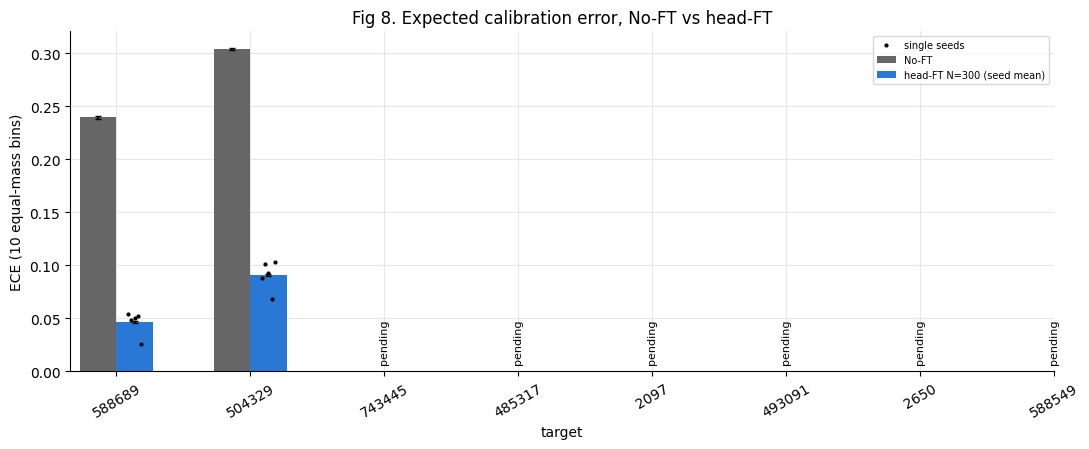

,target,base_rate,meanp_noft,meanp_ft,ECE_noft,ECE_ft,dECE_lo,dECE_hi,brier_noft,brier_ft,brier_constant
0,588689,0.0080,0.2475,0.0539,0.2395,0.0460,0.1927,0.1943,0.0749,0.0117,0.0079
1,504329,0.0088,0.3131,0.0993,0.3043,0.0905,0.2130,0.2145,0.1127,0.0200,0.0087


In [9]:
fig, ax = plt.subplots(figsize=(11, 4.6)); wd = .27
for i, t in enumerate(TARGETS):
    if t not in R: continue
    for dx, nm, c in [(-wd / 2, "No-FT", NEU), (wd / 2, "head-FT N=300 (seed mean)", OUR)]:
        v = R[t]["cal"][nm]; lo, hi = np.percentile(v["ece_boot"], [2.5, 97.5])
        ax.bar(i + dx, v["ece"], wd, color=c, label=nm if i == min(TARGETS.index(x) for x in R) else None); ax.errorbar(i + dx, v["ece"], yerr=[[v["ece"] - lo], [hi - v["ece"]]], color=BLK, capsize=2)
    ax.plot(np.full(5, i + wd / 2) + np.linspace(-.05, .05, 5), R[t]["cal"]["seeds300"], "k.", ms=4, label="single seeds" if i == min(TARGETS.index(x) for x in R) else None)
slot_axis(ax); ax.set_ylabel("ECE (10 equal-mass bins)"); ax.set_xlabel("target"); ax.set_title("Fig 8. Expected calibration error, No-FT vs head-FT"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
rows = []
for t in R:
    c = R[t]["cal"]; d = c["No-FT"]["ece_boot"] - c["head-FT N=300 (seed mean)"]["ece_boot"]
    rows.append(dict(target=SHORT[t], base_rate=R[t]["rate"], meanp_noft=c["No-FT"]["mean_p"], meanp_ft=c["head-FT N=300 (seed mean)"]["mean_p"], ECE_noft=c["No-FT"]["ece"],
                     ECE_ft=c["head-FT N=300 (seed mean)"]["ece"], dECE_lo=np.percentile(d, 2.5), dECE_hi=np.percentile(d, 97.5),
                     brier_noft=c["No-FT"]["brier"], brier_ft=c["head-FT N=300 (seed mean)"]["brier"], brier_constant=c["brier_base"]))
CAL = pd.DataFrame(rows); display(CAL.round(4))

## Part 4. Do the 5 seeds agree on the top-1%? (analysis 3)
Each seed's top-1% is its own k highest-scoring compounds (k = 1% of the eval set). Jaccard = |A and B| / |A or B| between two seeds; the expected Jaccard of two random 1% sets is about 0.005.

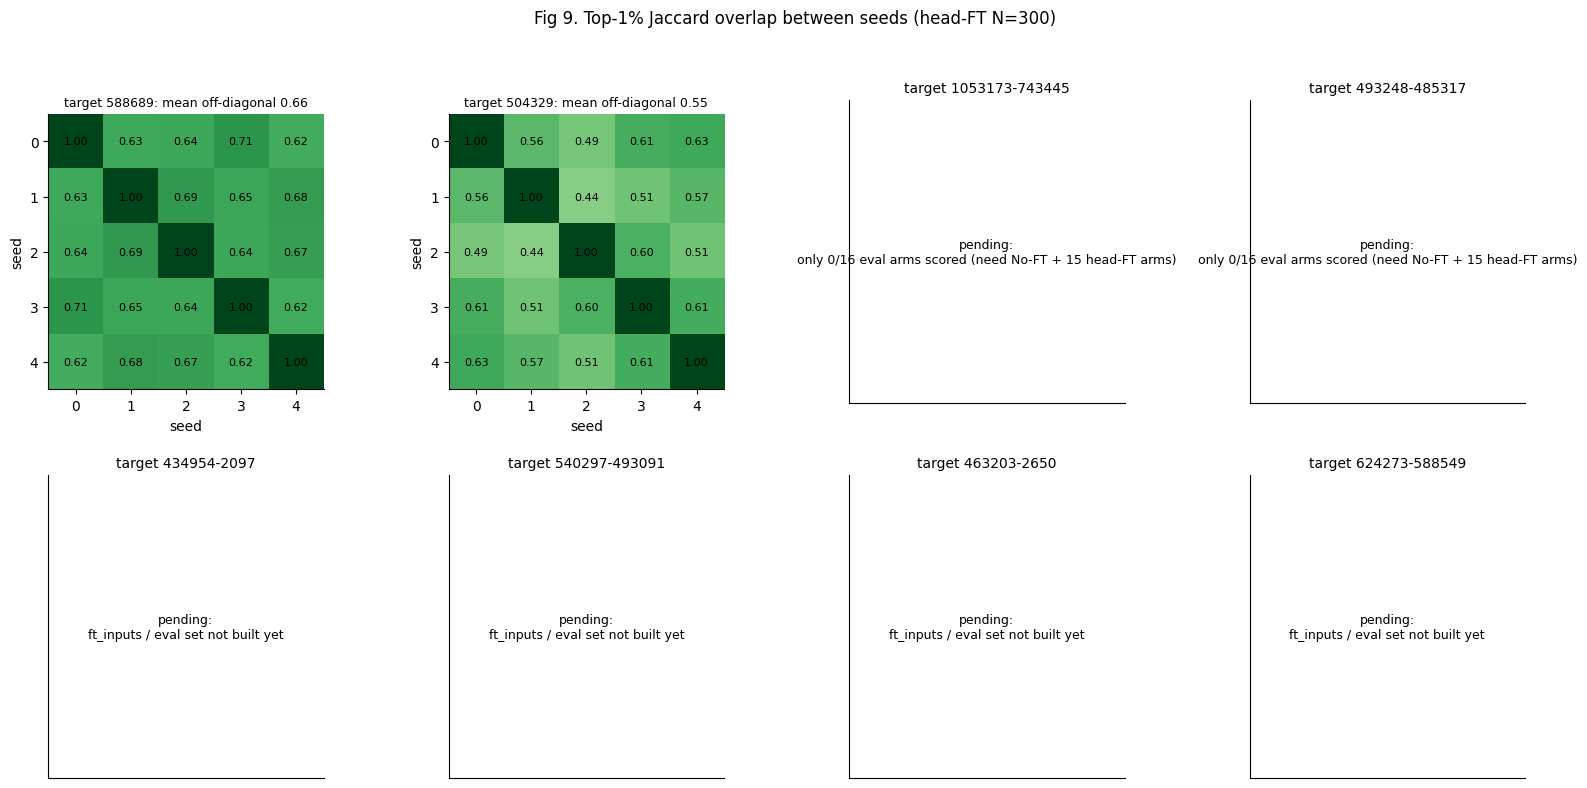

In [10]:
def d8(ax, t):
    J = R[t]["jac300"]; ax.imshow(J, vmin=0, vmax=1, cmap="Greens"); ax.grid(False)
    for i in range(5):
        for j in range(5): ax.text(j, i, f"{J[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_xticks(range(5)); ax.set_yticks(range(5)); ax.set_xlabel("seed"); ax.set_ylabel("seed")
    ax.set_title(f"target {t}: mean off-diagonal {J[np.triu_indices(5, 1)].mean():.2f}", fontsize=9)
panels(d8, "Fig 9. Top-1% Jaccard overlap between seeds (head-FT N=300)", figsize=(16, 8))

### Fig 10. Seed votes on the union of the five top-1% sets: how many compounds, how many are active
Bars: number of compounds in the top-1% of exactly v seeds (left axis, log). Markers: observed active rate of those compounds with Wilson 95% CI (right axis).

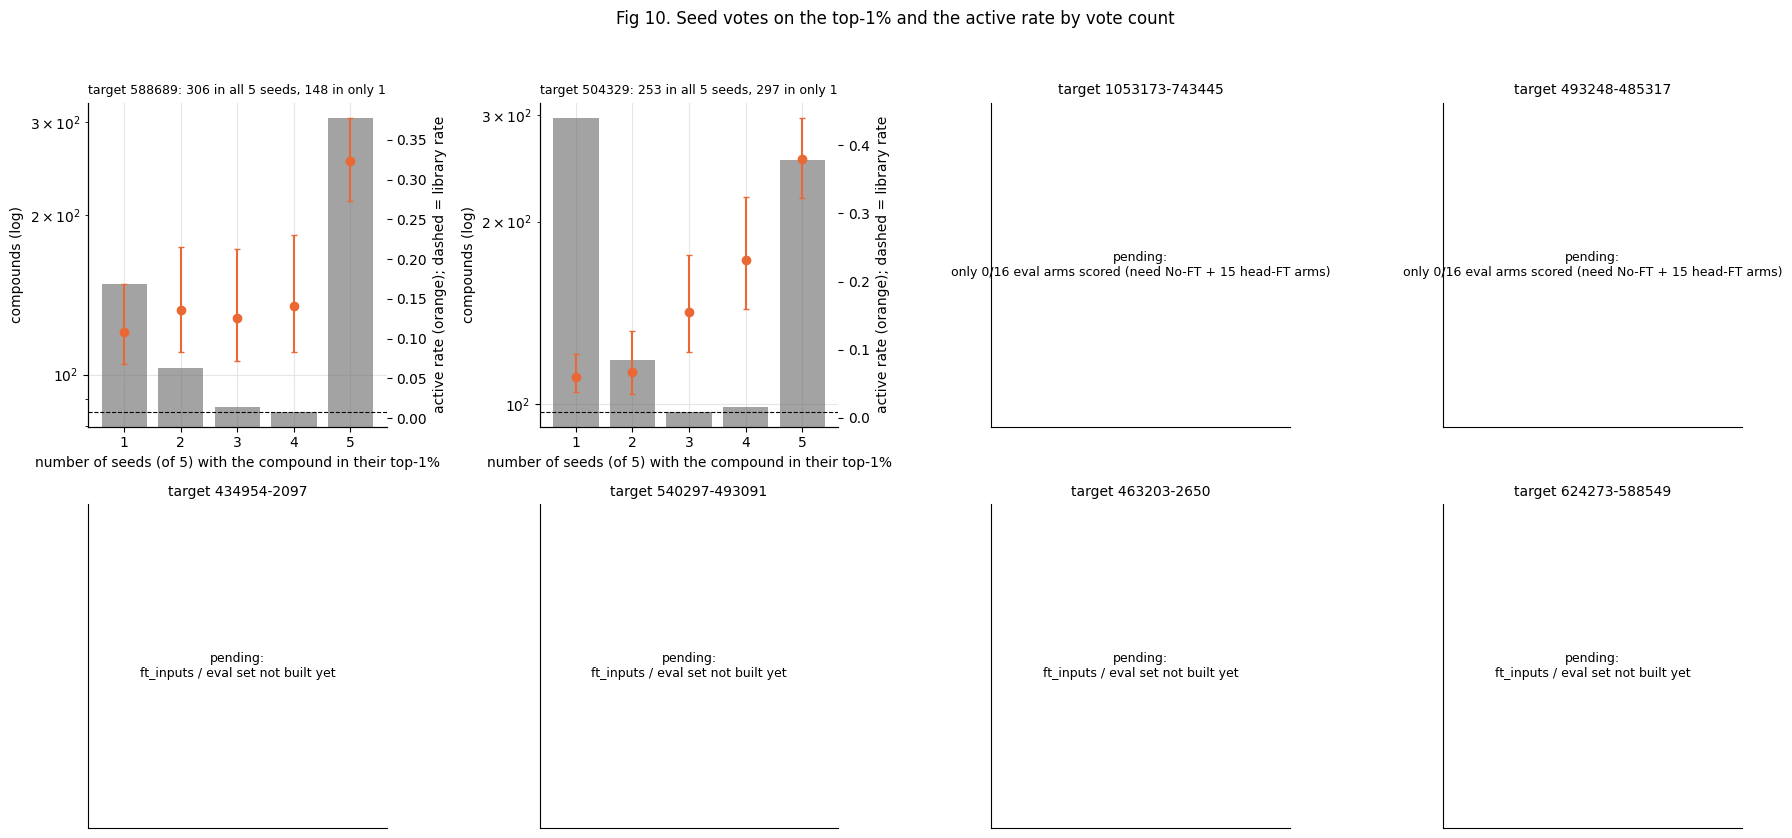

In [11]:
def d9(ax, t):
    vt = R[t]["vote_tab"]; ax.bar(vt.index, vt.n, color=NEU, alpha=.6); ax.set_yscale("log"); ax.set_xlabel("number of seeds (of 5) with the compound in their top-1%"); ax.set_ylabel("compounds (log)")
    ax2 = ax.twinx(); ax2.grid(False); pr = vt.actives / vt.n; ci = np.array([wilson(a, n) for a, n in zip(vt.actives, vt.n)])
    ax2.errorbar(vt.index, pr, yerr=[pr - ci[:, 0], ci[:, 1] - pr], fmt="o", color=THEIR, capsize=2); ax2.axhline(R[t]["rate"], color=BLK, ls="--", lw=.8); ax2.set_ylabel("active rate (orange); dashed = library rate")
    ax.set_title(f"target {t}: {int(vt.n[5])} in all 5 seeds, {int(vt.n[1])} in only 1", fontsize=9)
panels(d9, "Fig 10. Seed votes on the top-1% and the active rate by vote count")

### Fig 11. Seed agreement vs label budget (mean and range over the 10 seed pairs)

pending: 1053173-743445 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 493248-485317 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 434954-2097 - ft_inputs / eval set not built yet
pending: 540297-493091 - ft_inputs / eval set not built yet
pending: 463203-2650 - ft_inputs / eval set not built yet
pending: 624273-588549 - ft_inputs / eval set not built yet


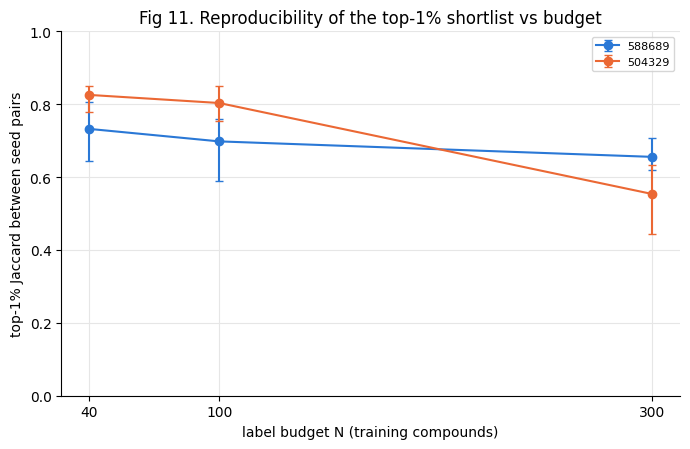

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.6))
for t in R:
    mu = [R[t]["jac"][N].mean() for N in BUDGETS]; lo = [R[t]["jac"][N].min() for N in BUDGETS]; hi = [R[t]["jac"][N].max() for N in BUDGETS]
    ax.errorbar(BUDGETS, mu, yerr=[np.array(mu) - lo, np.array(hi) - mu], marker="o", color=TCOL[t], capsize=3, label=SHORT[t])
for t in TARGETS:
    if t not in R: print("pending:", t, "-", PEND[t])
ax.set_xticks(BUDGETS); ax.set_xlabel("label budget N (training compounds)"); ax.set_ylabel("top-1% Jaccard between seed pairs"); ax.set_ylim(0, 1); ax.legend(fontsize=8)
ax.set_title("Fig 11. Reproducibility of the top-1% shortlist vs budget"); plt.tight_layout(); plt.show()

## Part 5. Precision and recall of confident (seed-unanimous) subsets (analysis 4)
Sets defined by votes (of 5 seeds), plus the seed-mean top-1% and the seed-mean top-u, where u is the size of the unanimous set (same size, so precision is comparable). CIs are bootstrap over compounds with the set held fixed.

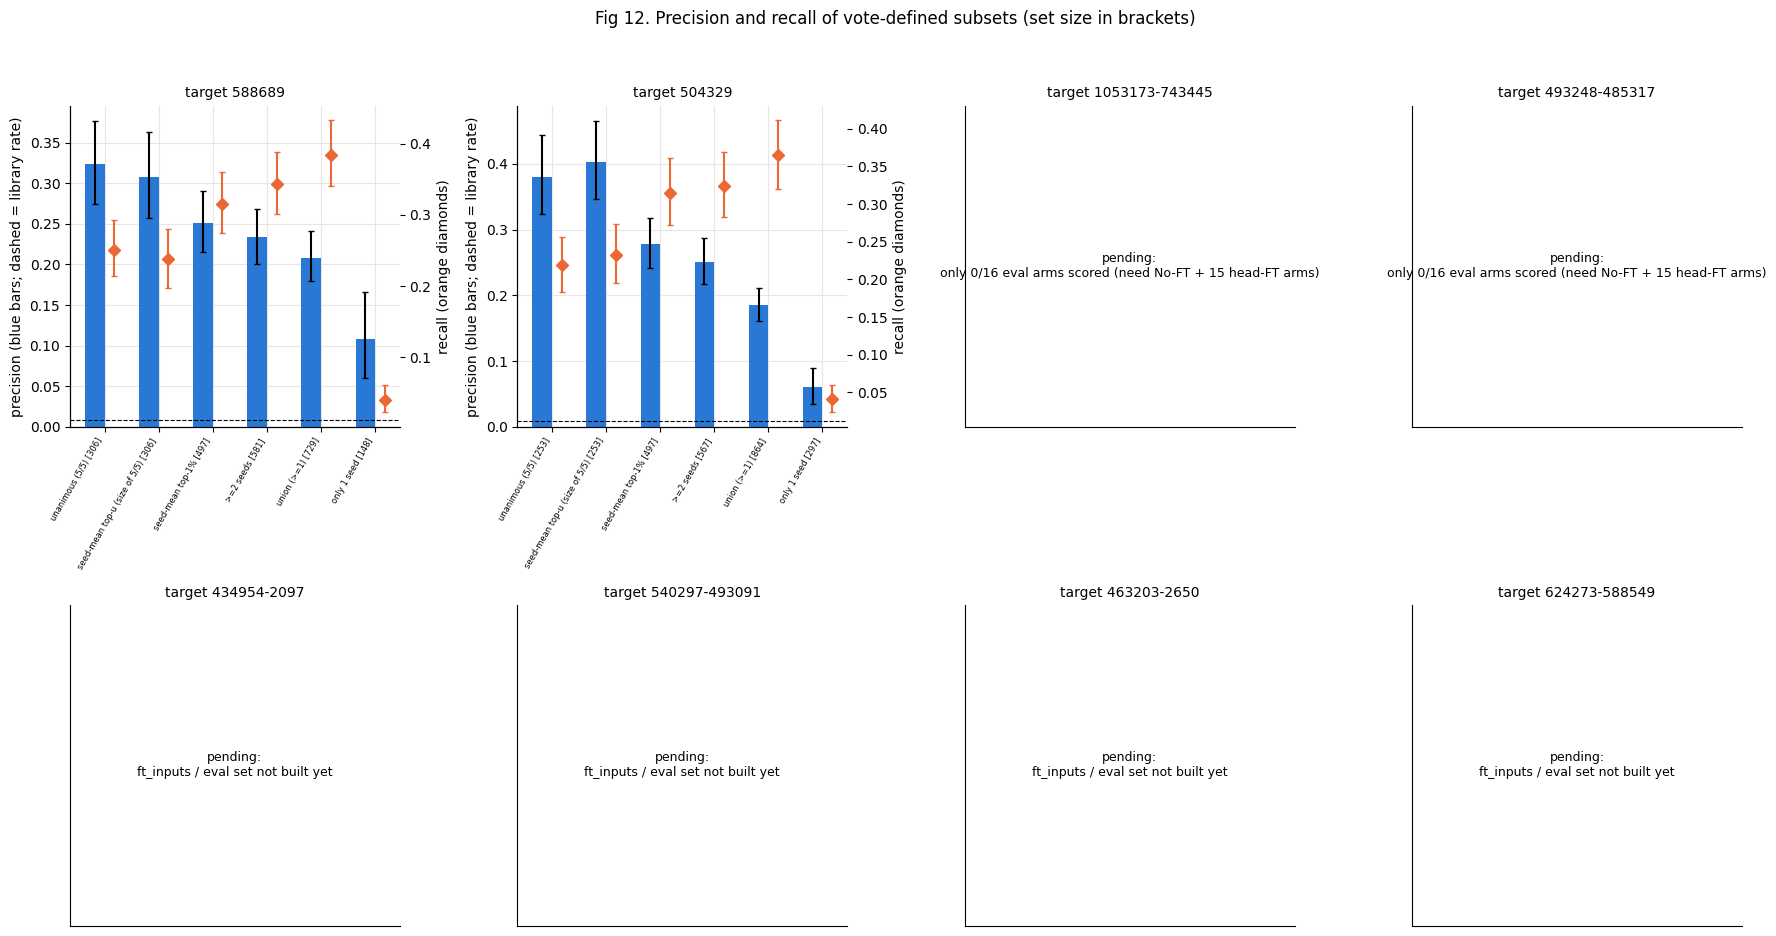

In [13]:
NAMES = ["unanimous (5/5)", "seed-mean top-u (size of 5/5)", "seed-mean top-1%", ">=2 seeds", "union (>=1)", "only 1 seed"]
def d10(ax, t):
    S = R[t]["sets"]; x = np.arange(len(NAMES)); ax2 = ax.twinx(); ax2.grid(False)
    for i, nm in enumerate(NAMES):
        v = S.get(nm)
        if v is None: continue
        ax.bar(i - .18, v["prec"], .36, color=OUR, yerr=[[v["prec"] - v["prec_ci"][0]], [v["prec_ci"][1] - v["prec"]]], capsize=2, label="precision" if i == 0 else None)
        ax2.errorbar(i + .18, v["rec"], yerr=[[v["rec"] - v["rec_ci"][0]], [v["rec_ci"][1] - v["rec"]]], fmt="D", color=THEIR, capsize=2, label="recall" if i == 0 else None)
    ax.axhline(R[t]["rate"], color=BLK, ls="--", lw=.8); ax.set_xticks(x); ax.set_xticklabels([f"{n} [{S[n]['size']}]" if S.get(n) else n for n in NAMES], rotation=60, ha="right", fontsize=6)
    ax.set_ylabel("precision (blue bars; dashed = library rate)"); ax2.set_ylabel("recall (orange diamonds)")
panels(d10, "Fig 12. Precision and recall of vote-defined subsets (set size in brackets)", figsize=(18, 9.5))

### Fig 13. Precision-recall trajectory: tightening the vote threshold vs simply shortening the seed-mean list
Line: top-m of the seed-mean probability for m = k/2 ... 4k. Labelled markers: sets with at least v seed votes. Markers on or above the line mean a vote threshold is at least as good as a plain cut at the same recall.

pending: 1053173-743445 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 493248-485317 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 434954-2097 - ft_inputs / eval set not built yet
pending: 540297-493091 - ft_inputs / eval set not built yet
pending: 463203-2650 - ft_inputs / eval set not built yet
pending: 624273-588549 - ft_inputs / eval set not built yet


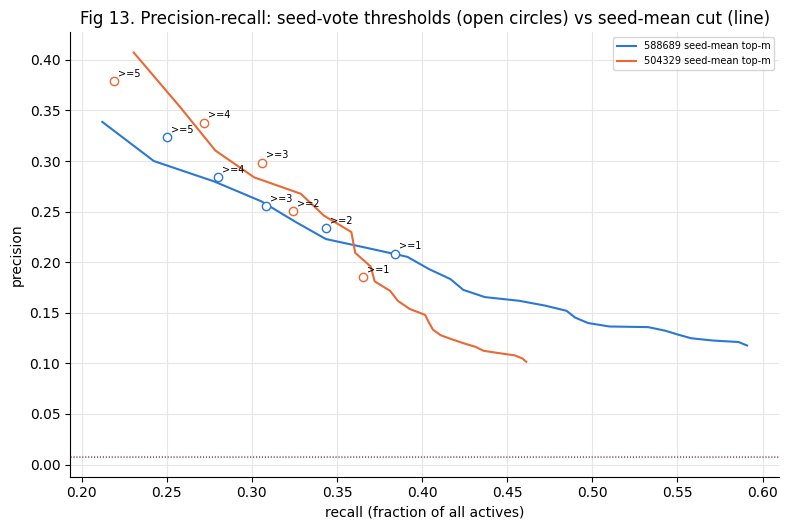

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.4))
for t in R:
    pc = R[t]["pr_curve"]; ax.plot(pc.rec, pc.prec, "-", color=TCOL[t], label=f"{SHORT[t]} seed-mean top-m")
    S = R[t]["sets"]; pts = [(S[nm]["rec"], S[nm]["prec"], v) for v, nm in zip([5, 4, 3, 2, 1], ["unanimous (5/5)", ">=4 seeds", ">=3 seeds", ">=2 seeds", "union (>=1)"]) if S.get(nm)]
    ax.plot([p[0] for p in pts], [p[1] for p in pts], "o", color=TCOL[t], mfc="white")
    for r_, p_, v in pts: ax.annotate(f">={v}", (r_, p_), fontsize=7, xytext=(3, 3), textcoords="offset points")
    ax.axhline(R[t]["rate"], color=TCOL[t], ls=":", lw=.8)
for t in TARGETS:
    if t not in R: print("pending:", t, "-", PEND[t])
ax.set_xlabel("recall (fraction of all actives)"); ax.set_ylabel("precision"); ax.legend(fontsize=7)
ax.set_title("Fig 13. Precision-recall: seed-vote thresholds (open circles) vs seed-mean cut (line)"); plt.tight_layout(); plt.show()

## Part 6. Uncertainty of the ranking metric itself (analysis 5)
AP across the 5 seeds (dots, mean, SD) and a bootstrap 95% CI over compounds for the seed-averaged AP (same resamples for every arm, so ratios are paired). Orange squares are the paper's values (fixed, from `trainer_control.csv`); the dotted line is the random-ranking AP (= active rate).

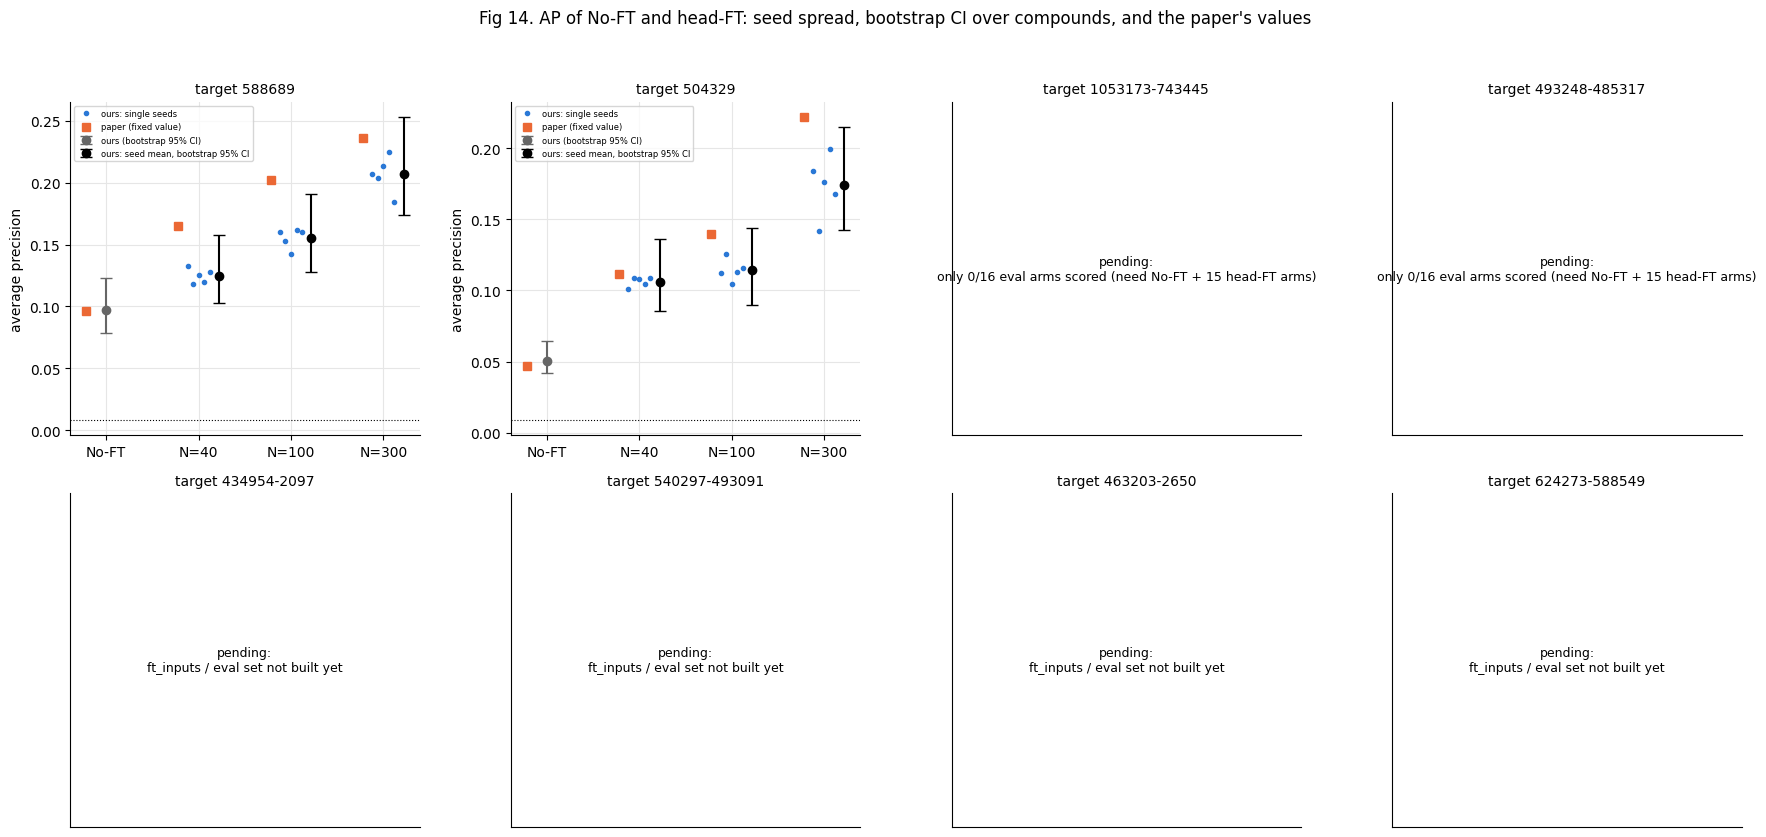

In [15]:
def d11(ax, t):
    a = R[t]["ap"]; xs = [0] + [1, 2, 3]
    lo, hi = np.percentile(a["noft_boot"], [2.5, 97.5]); ax.errorbar(0, a["noft"], yerr=[[a["noft"] - lo], [hi - a["noft"]]], fmt="o", color=NEU, capsize=4, label="ours (bootstrap 95% CI)")
    for j, N in enumerate(BUDGETS, 1):
        f = a["ft"][N]; lo, hi = np.percentile(f["boot_mean"], [2.5, 97.5])
        ax.plot(np.full(5, j) + np.linspace(-.12, .12, 5), f["seeds"], ".", color=OUR, ms=6, label="ours: single seeds" if j == 1 else None)
        ax.errorbar(j + .22, f["mean"], yerr=[[f["mean"] - lo], [hi - f["mean"]]], fmt="o", color=BLK, capsize=4, label="ours: seed mean, bootstrap 95% CI" if j == 1 else None)
        try: ax.plot(j - .22, PAPER_FT.loc[(t, N), "auprc"], "s", color=THEIR, label="paper (fixed value)" if j == 1 else None)
        except KeyError: pass
    ax.plot(-.22, PAPER_BASE.loc[t, "auprc"], "s", color=THEIR)
    ax.axhline(R[t]["rate"], color=BLK, ls=":", lw=.8); ax.set_xticks(range(4)); ax.set_xticklabels(["No-FT", "N=40", "N=100", "N=300"]); ax.set_ylabel("average precision"); ax.legend(fontsize=6)
panels(d11, "Fig 14. AP of No-FT and head-FT: seed spread, bootstrap CI over compounds, and the paper's values")

### Fig 15. Which uncertainty dominates: seed-to-seed or sampling of compounds? And the FT / No-FT AP ratio with its CI
Left: SD of AP over the 5 seeds (x) against the bootstrap SD over compounds of the seed-averaged AP (y), one marker per target and budget; points above the diagonal mean compound sampling dominates. Right: paired-bootstrap ratio AP(FT N=300 seed mean) / AP(No-FT) with its 95% CI; orange = paper ratio (fixed paper values).

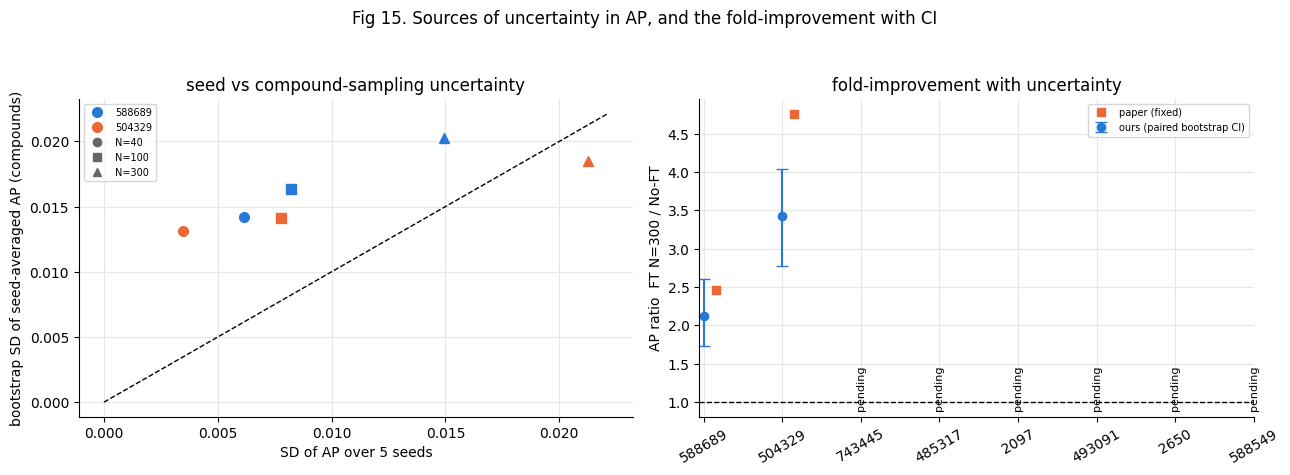

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8)); ax = axes[0]; mk = {40: "o", 100: "s", 300: "^"}
for t in R:
    for N in BUDGETS:
        f = R[t]["ap"]["ft"][N]; ax.plot(f["sd"], np.std(f["boot_mean"], ddof=1), mk[N], color=TCOL[t], ms=7, label=f"{SHORT[t]}" if N == 40 else None)
mx = max([ax.get_xlim()[1], ax.get_ylim()[1]]); ax.plot([0, mx], [0, mx], "--", color=BLK, lw=1)
for N in BUDGETS: ax.plot([], [], mk[N], color=NEU, label=f"N={N}")
ax.set_xlabel("SD of AP over 5 seeds"); ax.set_ylabel("bootstrap SD of seed-averaged AP (compounds)"); ax.set_title("seed vs compound-sampling uncertainty"); ax.legend(fontsize=7)
ax = axes[1]
for i, t in enumerate(TARGETS):
    if t not in R: continue
    a = R[t]["ap"]; rt = a["ft"][300]["mean"] / a["noft"]; b = a["ft"][300]["boot_mean"] / a["noft_boot"]; lo, hi = np.nanpercentile(b, [2.5, 97.5])
    ax.errorbar(i, rt, yerr=[[rt - lo], [hi - rt]], fmt="o", color=OUR, capsize=4, label="ours (paired bootstrap CI)" if i == min(TARGETS.index(x) for x in R) else None)
    ax.plot(i + .15, PAPER_FT.loc[(t, 300), "auprc"] / PAPER_BASE.loc[t, "auprc"], "s", color=THEIR, label="paper (fixed)" if i == min(TARGETS.index(x) for x in R) else None)
ax.axhline(1, color=BLK, ls="--", lw=1); slot_axis(ax); ax.set_ylabel("AP ratio  FT N=300 / No-FT"); ax.set_title("fold-improvement with uncertainty"); ax.legend(fontsize=7)
fig.suptitle("Fig 15. Sources of uncertainty in AP, and the fold-improvement with CI", fontsize=12); plt.tight_layout(rect=[0, 0, 1, .94]); plt.show()

### Fig 16. Does more training data reduce the uncertainty? (top-1% picks, mean over compounds)

pending: 1053173-743445 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 493248-485317 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 434954-2097 - ft_inputs / eval set not built yet
pending: 540297-493091 - ft_inputs / eval set not built yet
pending: 463203-2650 - ft_inputs / eval set not built yet
pending: 624273-588549 - ft_inputs / eval set not built yet


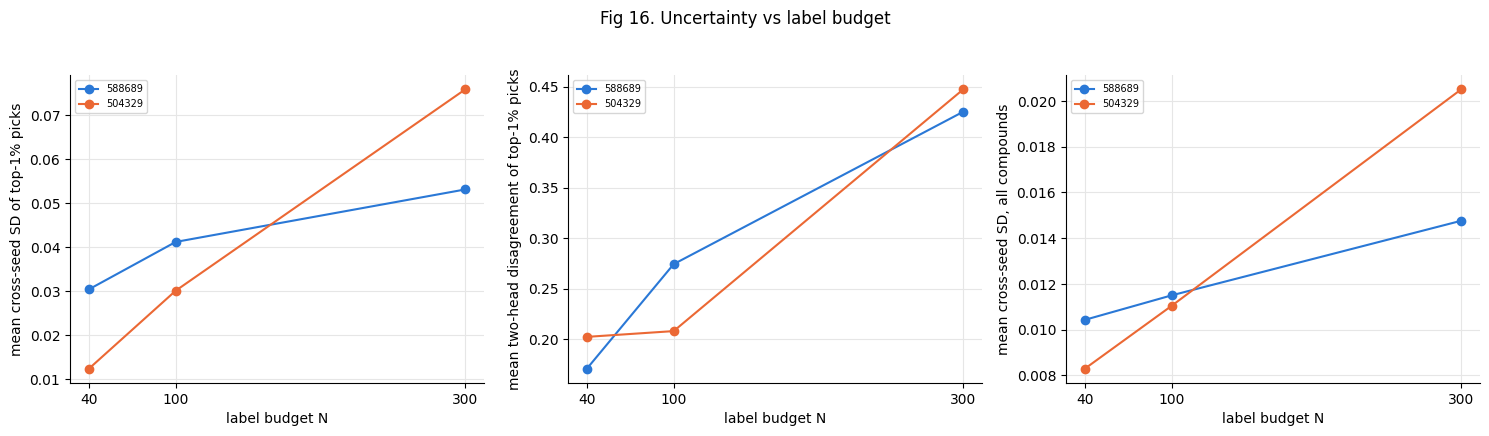

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for col, (key, lab) in zip(axes, [("sd_top", "mean cross-seed SD of top-1% picks"), ("dis_top", "mean two-head disagreement of top-1% picks"), ("sd_all", "mean cross-seed SD, all compounds")]):
    for t in R: col.plot(BUDGETS, R[t]["budget"][key], "o-", color=TCOL[t], label=SHORT[t])
    col.set_xticks(BUDGETS); col.set_xlabel("label budget N"); col.set_ylabel(lab); col.legend(fontsize=7)
for t in TARGETS:
    if t not in R: print("pending:", t, "-", PEND[t])
fig.suptitle("Fig 16. Uncertainty vs label budget", fontsize=12); plt.tight_layout(rect=[0, 0, 1, .94]); plt.show()

## Part 7. Pose confidence (ligand ipTM / PDE) - only where Boltz-2 poses were scored
Structural confidence comes from `results/runs/<target>/qc.csv` (Boltz-2 confidence of the folded complexes). Targets without that file are marked pending; its coverage can be a subset of the eval set (see the `n_used` column of the table after Fig 4).

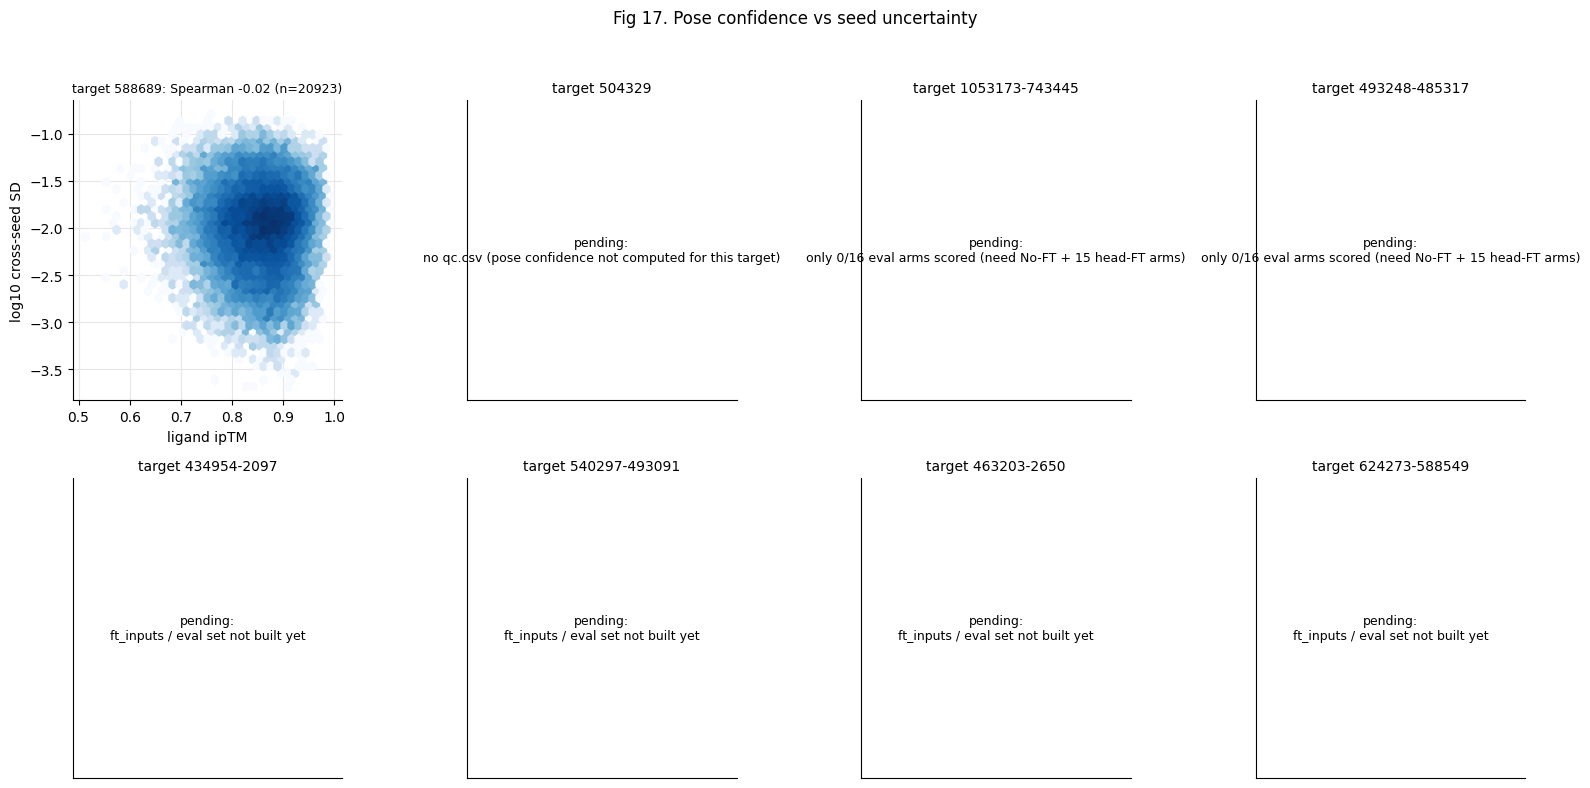

In [18]:
def d12(ax, t):
    d = D[t]
    if not d["has_pose"]: raise Pend("no qc.csv (pose confidence not computed for this target)")
    ok = np.isfinite(d["iptm"]); x = -d["iptm"][ok]; yv = np.log10(d["sd"][ok] + 1e-6)
    hb = ax.hexbin(x, yv, gridsize=35, cmap="Blues", mincnt=1, bins="log"); rho = stats.spearmanr(x, yv)[0]
    ax.set_xlabel("ligand ipTM"); ax.set_ylabel("log10 cross-seed SD"); ax.set_title(f"target {t}: Spearman {rho:.2f} (n={ok.sum()})", fontsize=9)
panels(d12, "Fig 17. Pose confidence vs seed uncertainty", figsize=(16, 8))

## Part 8. What chemistry is uncertain?
Spearman correlation between RDKit properties (random sample of about 9000 compounds plus all top-1% picks) and the within-score-band percentile rank of the uncertainty, so score effects are removed. Descriptive only; 9 properties x 2 measures x targets are many comparisons, so read the pattern, not single cells.

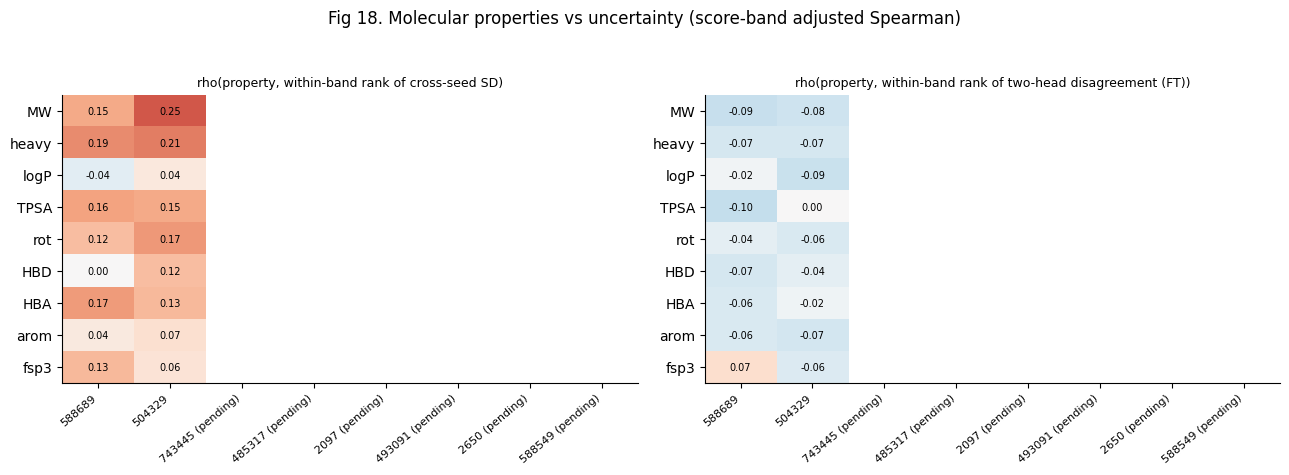

In [19]:
DESC = {}
for t in R:
    try: DESC[t] = descriptors(D[t])
    except Exception as e: print(f"{SHORT[t]}: descriptor step failed: {e}")
PR = ["MW", "heavy", "logP", "TPSA", "rot", "HBD", "HBA", "arom", "fsp3"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (m, lab) in zip(axes, [("sd_rank", "cross-seed SD"), ("dis_ft_rank", "two-head disagreement (FT)")]):
    M = np.full((len(PR), len(TARGETS)), np.nan)
    for j, t in enumerate(TARGETS):
        if t in DESC: M[:, j] = [stats.spearmanr(DESC[t][p], DESC[t][m])[0] for p in PR]
    ax.imshow(M, vmin=-.4, vmax=.4, cmap="RdBu_r", aspect="auto"); ax.grid(False)
    ax.set_xticks(range(len(TARGETS))); ax.set_xticklabels([SHORT[t] + ("" if t in DESC else " (pending)") for t in TARGETS], rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(PR))); ax.set_yticklabels(PR)
    for i in range(len(PR)):
        for j in range(len(TARGETS)):
            if np.isfinite(M[i, j]): ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"rho(property, within-band rank of {lab})", fontsize=9)
fig.suptitle("Fig 18. Molecular properties vs uncertainty (score-band adjusted Spearman)", fontsize=12); plt.tight_layout(rect=[0, 0, 1, .94]); plt.show()

### Fig 19. Molecules: seed-unanimous picks (top row) vs picks made by only one seed (bottom row)
Structures of the four highest-scoring compounds in each group, with label and cross-seed SD. One figure per filled target.

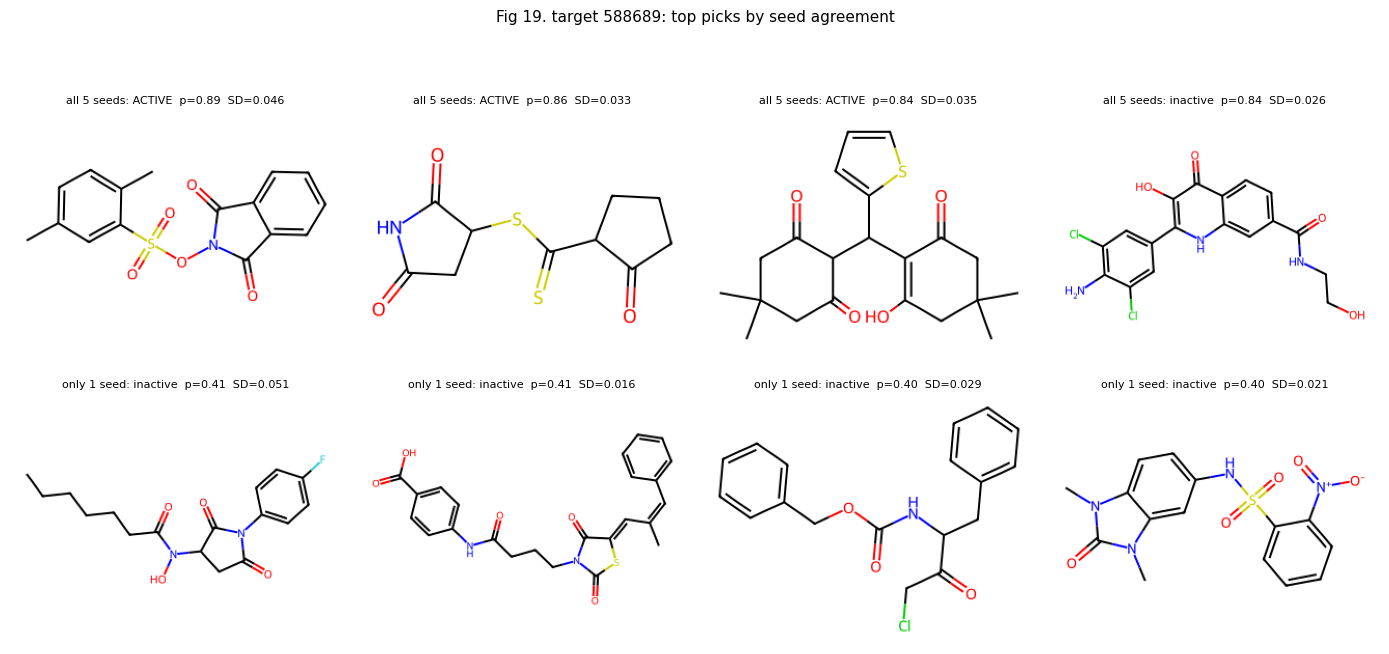

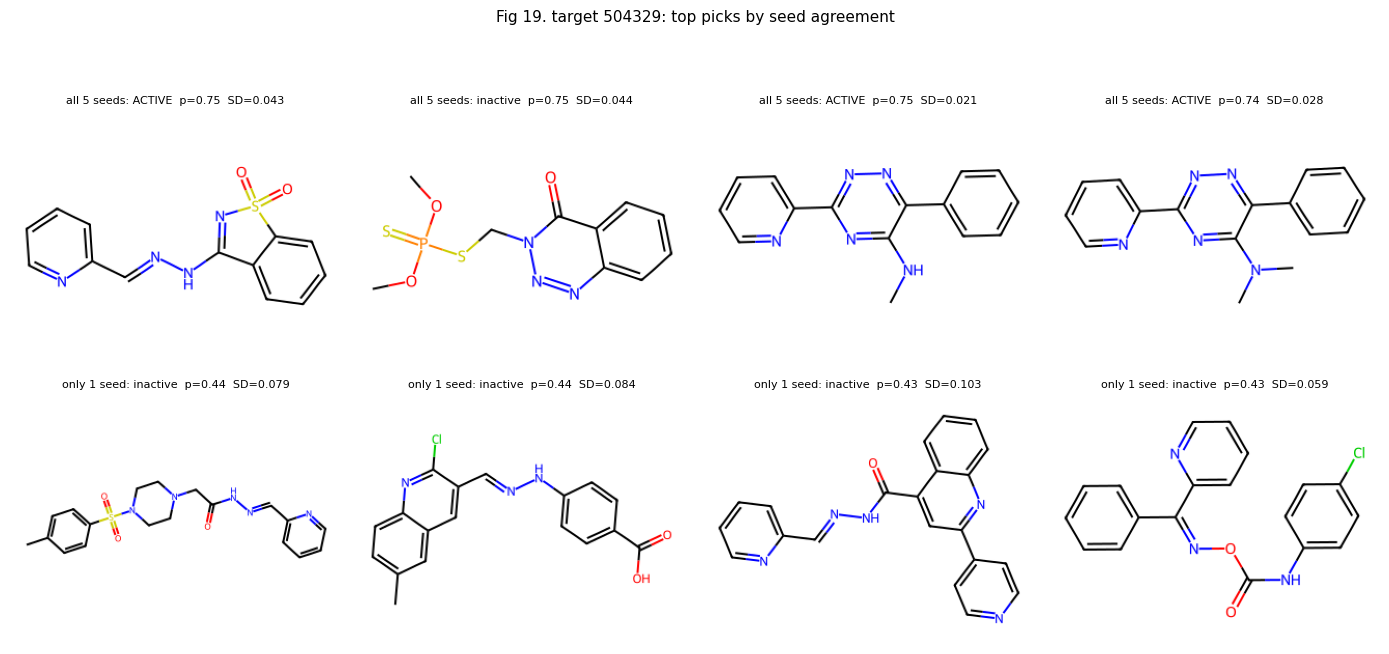

pending: 1053173-743445 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 493248-485317 - only 0/16 eval arms scored (need No-FT + 15 head-FT arms)
pending: 434954-2097 - ft_inputs / eval set not built yet
pending: 540297-493091 - ft_inputs / eval set not built yet
pending: 463203-2650 - ft_inputs / eval set not built yet
pending: 624273-588549 - ft_inputs / eval set not built yet


In [20]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")
for t in TARGETS:
    if t not in R: print("pending:", t, "-", PEND[t]); continue
    d = D[t]; v = R[t]["votes"]; fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for r_, (sel, nm) in enumerate([(v == 5, "all 5 seeds"), (v == 1, "only 1 seed")]):
        idx = np.where(sel)[0]; idx = idx[np.argsort(-d["pm"][idx])][:4]
        for c_, ax in enumerate(axes[r_]):
            ax.axis("off")
            if c_ >= len(idx): continue
            i = idx[c_]; m = Chem.MolFromSmiles(d["S"].smiles.iat[i]) if isinstance(d["S"].smiles.iat[i], str) else None
            if m is not None: ax.imshow(Draw.MolToImage(m, size=(320, 240)))
            ax.set_title(f"{nm}: {'ACTIVE' if d['y'][i] else 'inactive'}  p={d['pm'][i]:.2f}  SD={d['sd'][i]:.3f}", fontsize=8)
    fig.suptitle(f"Fig 19. target {t}: top picks by seed agreement", fontsize=11); plt.tight_layout(rect=[0, 0, 1, .95]); plt.show()

## Part 9. Per-target summary table (analysis 6)
Paper columns are fixed paper values (trainer_control.csv); all other columns are computed here. Pooled row = across-target mean (targets as units).

In [21]:
rows = []
for t in TARGETS:
    if t not in R: rows.append(dict(target=SHORT[t], status="pending: " + PEND[t])); continue
    r = R[t]; a = r["ap"]; f = a["ft"][300]; b = f["boot_mean"] / a["noft_boot"]; S = r["sets"]; sdv = r["rr"]["sd"]; lo, hi = np.nanpercentile(sdv["boot"], [0.5, 99.5])
    d = S.get("_diff_unan_vs_topu")
    rows.append(dict(target=SHORT[t], n_eval=r["n"], n_act=r["n_act"], AP_noft=a["noft"], AP_noft_paper=PAPER_BASE.loc[t, "auprc"], AP_ft300=f["mean"], AP_ft300_sd=f["sd"],
                     AP_ft300_paper=PAPER_FT.loc[(t, 300), "auprc"], ratio=f["mean"] / a["noft"], ratio_lo=np.nanpercentile(b, 2.5), ratio_hi=np.nanpercentile(b, 97.5),
                     ratio_paper=PAPER_FT.loc[(t, 300), "auprc"] / PAPER_BASE.loc[t, "auprc"], AP_boot_CI_width=np.subtract(*np.percentile(f["boot_mean"], [97.5, 2.5])),
                     ECE_noft=r["cal"]["No-FT"]["ece"], ECE_ft=r["cal"]["head-FT N=300 (seed mean)"]["ece"], jaccard_N300=r["jac300"][np.triu_indices(5, 1)].mean(),
                     n_unanimous=int((r["votes"] == 5).sum()), n_only1=int((r["votes"] == 1).sum()), prec_unanimous=S["unanimous (5/5)"]["prec"] if S.get("unanimous (5/5)") else np.nan,
                     prec_topu=S["seed-mean top-u (size of 5/5)"]["prec"] if S.get("seed-mean top-u (size of 5/5)") else np.nan, RR_sd=sdv["rr"], RR_sd_lo=lo, RR_sd_hi=hi))
SUM = pd.DataFrame(rows).set_index("target"); display(SUM.round(3))
fl = SUM.drop(columns=[c for c in SUM if c == "status"], errors="ignore").select_dtypes("number")
if len(R): print(f"\nAcross-target mean over {len(R)} target(s):"); display(fl.mean().round(3).to_frame("mean").T)

,n_eval,n_act,AP_noft,AP_noft_paper,AP_ft300,AP_ft300_sd,AP_ft300_paper,ratio,ratio_lo,ratio_hi,...,ECE_ft,jaccard_N300,n_unanimous,n_only1,prec_unanimous,prec_topu,RR_sd,RR_sd_lo,RR_sd_hi,status
target,,,,,,,,,,,,,,,,,,,,,
588689,49685.0,396.0,0.097,0.096,0.207,0.015,0.237,2.124,1.734,2.604,...,0.046,0.656,306.0,148.0,0.324,0.307,0.751,0.590,0.978,NaN
504329,49673.0,438.0,0.051,0.047,0.174,0.021,0.222,3.424,2.771,4.045,...,0.091,0.554,253.0,297.0,0.379,0.403,0.971,0.774,1.227,NaN
743445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: only 0/16 eval arms scored (need No-F...
485317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: only 0/16 eval arms scored (need No-F...
2097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: ft_inputs / eval set not built yet
493091,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: ft_inputs / eval set not built yet
2650,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: ft_inputs / eval set not built yet
588549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pending: ft_inputs / eval set not built yet



Across-target mean over 2 target(s):


,n_eval,n_act,AP_noft,AP_noft_paper,AP_ft300,AP_ft300_sd,AP_ft300_paper,ratio,ratio_lo,ratio_hi,...,ECE_noft,ECE_ft,jaccard_N300,n_unanimous,n_only1,prec_unanimous,prec_topu,RR_sd,RR_sd_lo,RR_sd_hi
mean,49679.0,417.0,0.074,0.071,0.19,0.018,0.229,2.774,2.253,3.325,...,0.272,0.068,0.605,279.5,222.5,0.351,0.355,0.861,0.682,1.102


## Conclusions (computed from the data above)
Every number below is an f-string over the analysis results; paper values are labelled fixed. Targets without data are listed as pending, and no statement is made for them.

In [22]:
def verdict(rr, lo, hi):
    if not np.isfinite(rr): return "not estimable"
    if lo > 1: return "confident half has a HIGHER active rate"
    if hi < 1: return "confident half has a LOWER active rate"
    return "no resolvable difference"
pend_list = [SHORT[t] for t in TARGETS if t not in R]
print(f"Targets analysed: {[SHORT[t] for t in R]}.  Pending (no statement made): {pend_list}.")
if NT < 3: print(f"CAUTION: pooled statements rest on {NT} target(s) (< 3): they are descriptive, with no cross-target interval.")
print("\n(1) Is confidence useful at matched score?  RR = active rate confident/uncertain half; Bonferroni 99% bootstrap CI (5 measures x targets tested).")
for m in MEAS:
    parts = []
    for t in R:
        v = R[t]["rr"].get(m)
        if v is None: parts.append(f"{SHORT[t]}: n/a (no pose confidence)"); continue
        lo, hi = np.nanpercentile(v["boot"], [0.5, 99.5]); parts.append(f"{SHORT[t]}: RR={v['rr']:.2f} [{lo:.2f},{hi:.2f}] -> {verdict(v['rr'], lo, hi)}")
    g = pooled([np.log(R[t]["rr"][m]["rr"]) for t in R if R[t]["rr"].get(m)])
    pl = "no target" if g[3] == 0 else (f"geometric mean RR={np.exp(g[0]):.2f} over {g[3]} target(s)" + (f", 95% t-interval [{np.exp(g[1]):.2f},{np.exp(g[2]):.2f}]" if g[1] is not None else ", interval undefined (<3 targets)"))
    print(f"  {MEAS[m]}: " + "; ".join(parts) + f". Pooled: {pl}.")
for t in R:
    rc = R[t]["riskcov"].get("sd")
    if rc: print(f"  {SHORT[t]}: among top-1% picks, precision of low-SD half {rc['prec_conf']:.3f} vs high-SD half {rc['prec_unc']:.3f} (n={rc['n_half']} each; picks overall {rc['base']:.3f}).")
print("\n(2) Calibration (mean predicted p vs library active rate; ECE; 95% bootstrap CI of ECE(No-FT) - ECE(FT)).")
for _, r in CAL.iterrows():
    print(f"  {r.target}: active rate {r.base_rate:.4f}; mean p No-FT {r.meanp_noft:.3f}, FT {r.meanp_ft:.3f}; ECE No-FT {r.ECE_noft:.3f}, FT {r.ECE_ft:.3f}; dECE CI [{r.dECE_lo:.3f},{r.dECE_hi:.3f}] -> "
          + ("FT better calibrated" if r.dECE_lo > 0 else "FT worse calibrated" if r.dECE_hi < 0 else "no resolvable ECE change") + f"; Brier No-FT {r.brier_noft:.4f}, FT {r.brier_ft:.4f}, constant-rate {r.brier_constant:.4f}.")
print("\n(3) Seed agreement on the top-1% (N=300).")
for t in R:
    r = R[t]; vt = r["vote_tab"]; jm = r["jac300"][np.triu_indices(5, 1)]; rnd = r["k"] / (2 * r["n"] - r["k"])
    print(f"  {SHORT[t]}: k={r['k']}; mean pairwise Jaccard {jm.mean():.2f} (range {jm.min():.2f}-{jm.max():.2f}; random expectation {rnd:.3f}); in all 5 seeds: {int(vt.n[5])} ({int(vt.actives[5])} active); only 1 seed: {int(vt.n[1])} ({int(vt.actives[1])} active); union {int(vt.n.sum())}.")
print("\n(4) Confident (seed-unanimous) subset vs all.")
for t in R:
    S = R[t]["sets"]; u = S.get("unanimous (5/5)"); tk = S.get("seed-mean top-1%"); df_ = S.get("_diff_unan_vs_topu")
    if u is None or tk is None: print(f"  {SHORT[t]}: no unanimous set"); continue
    print(f"  {SHORT[t]}: unanimous precision {u['prec']:.3f} [{u['prec_ci'][0]:.3f},{u['prec_ci'][1]:.3f}], recall {u['rec']:.3f}; seed-mean top-1% precision {tk['prec']:.3f}, recall {tk['rec']:.3f}; "
          f"vs the same-size seed-mean top-u: precision difference {df_['d']:+.3f} [{df_['ci'][0]:+.3f},{df_['ci'][1]:+.3f}] (fixed sets) -> " + ("unanimity adds precision beyond score" if df_["ci"][0] > 0 else "unanimity lowers precision" if df_["ci"][1] < 0 else "no resolvable gain beyond the score itself") + ".")
print("\n(5) Uncertainty of the ranking metric (paper values are fixed).")
for t in R:
    a = R[t]["ap"]; f = a["ft"][300]; b = f["boot_mean"] / a["noft_boot"]; ci = np.nanpercentile(f["boot_mean"], [2.5, 97.5]); ns = np.percentile(a["noft_boot"], [2.5, 97.5])
    print(f"  {SHORT[t]}: No-FT AP {a['noft']:.3f} [{ns[0]:.3f},{ns[1]:.3f}] (paper {PAPER_BASE.loc[t, 'auprc']:.3f}); FT N=300 AP {f['mean']:.3f} +/- {f['sd']:.3f} over 5 seeds, bootstrap CI [{ci[0]:.3f},{ci[1]:.3f}] "
          f"(paper {PAPER_FT.loc[(t, 300), 'auprc']:.3f}); ratio x{f['mean'] / a['noft']:.2f} [{np.nanpercentile(b, 2.5):.2f},{np.nanpercentile(b, 97.5):.2f}] (paper x{PAPER_FT.loc[(t, 300), 'auprc'] / PAPER_BASE.loc[t, 'auprc']:.2f}); "
          f"bootstrap SD of seed-averaged AP {np.std(f['boot_mean'], ddof=1):.3f} vs seed SD {f['sd']:.3f}.")
print("\nLimits: bootstraps resample compounds only (the 5 seeds are the only model-side replicates; the training set of each budget is fixed, so training-set sampling variance is not included); "
      "RR groups and vote sets are held fixed in the bootstrap; Jaccard overlaps have no resampling CI (range over 10 seed pairs shown); pose-confidence rows exist only for targets with qc.csv and may cover a subset of compounds; "
      "many comparisons were made (5 measures x targets, plus per-panel p-values): only the Bonferroni-adjusted intervals in Fig 4 should be read as tests.")

Targets analysed: ['588689', '504329'].  Pending (no statement made): ['743445', '485317', '2097', '493091', '2650', '588549'].
CAUTION: pooled statements rest on 2 target(s) (< 3): they are descriptive, with no cross-target interval.

(1) Is confidence useful at matched score?  RR = active rate confident/uncertain half; Bonferroni 99% bootstrap CI (5 measures x targets tested).
  cross-seed SD (FT N=300): 588689: RR=0.75 [0.59,0.98] -> confident half has a LOWER active rate; 504329: RR=0.97 [0.77,1.23] -> no resolvable difference. Pooled: geometric mean RR=0.85 over 2 target(s), interval undefined (<3 targets).
  two-head disagreement (FT N=300): 588689: RR=1.83 [1.44,2.38] -> confident half has a HIGHER active rate; 504329: RR=0.99 [0.78,1.20] -> no resolvable difference. Pooled: geometric mean RR=1.34 over 2 target(s), interval undefined (<3 targets).
  two-head disagreement (No-FT): 588689: RR=1.19 [0.93,1.58] -> no resolvable difference; 504329: RR=0.84 [0.66,1.06] -> no resolvabl